# 🧠 Avanços em Inteligência artificial (IA)

<font color="blue"><b>Código - PPGEE-UFPR</b>: EELT7025</font>

**Disciplina**: Métodos avançados em sistemas eletrônicos – Avanços em Inteligência Artificial

**Local:** Centro Politécnico da UFPR,  sala DELT PL-05

**Carga horária**: 60 horas (4 créditos).

**Professor**: Leandro dos Santos Coelho (e-mail de contato: leandro.coelho@ufpr.br)

**Material de aula e códigos Python no Microsoft Teams:** 2026/2 - PPGEE - EELT7025 - Avanços em IA


# 🔋 **Otimização de hiperparâmetros em Aprendizado de Máquina**

A otimização de hiperparâmetros é o processo de encontrar a melhor combinação de configurações externas para treinar um modelo de Aprendizado de Máquina ou de Aprendizado profundo (*deep learning*).

Diferente dos **parâmetros internos** (como os pesos de uma rede neural artificial, que o algoritmo aprende sozinho durante o treino), os **hiperparâmetros** são definidos pelo projetista antes do treinamento começar tais como a taxa de aprendizado (*learning rate*), a profundidade máxima de uma árvore de decisão ou a quantidade de camadas de uma rede neural artificial.

Otimizar esses valores é fundamental para maximizar a precisão do algoritmo, evitar o sobretreinamento (quando o modelo decora os dados de treino mas "erra" com dados novos) e garantir o melhor desempenho possível.

---

## <font color="blue">**Estrutura para a <font color="red">Aula 05**</font>


| # | Módulo | Conteúdo |
|---|--------|----------|
| 1 | **Configuração** | Instalação, imports e dataset UCI Power Consumption |
| 2 | **Teoria** | Por que otimizar? Compromisso viés-variância, formalização |
| 3 | **Métodos clássicos** | Análise comparativa de busca em grade e busca aleatória |
| 4 | **Processo Gaussiano** | Fundamentos, kernels, posterior, aquisição |
| 5 | **Otimização Bayesiana** | skopt, bayes_opt, Optuna, Hyperopt, Ray Tune |
| 6 | **Metaheurísticas** | Algoritmo genético, Evolução diferencial, Exame de partículas (PSO) |
| 7 | **Comparação de abordagens** | Métricas de desempenho e custo computacional |

---

### <font color="blue">**Aplicação**</font>

💡 **Conjunto de dados:** UCI Individual Household Electric Power Consumption (2M+ registros, 2006–2010)  

**Referência**:

**Hébrail, G., Bérard, A. (2012).** Individual household electric power consumption. UCI Machine Learning Repository. Disponível em: https://archive.ics.uci.edu/dataset/235/.

# 🛠️**Configuração do ambiente**


### **Instala bibliotecas**

Lista de bibliotecas instaladas:

* **[ucimlrepo](https://github.com/uci-ml-repo/ucimlrepo)**: Interface para importar diretamente conjuntos de dados do repositório UCI Machine Learning.
* **[scikit-optimize (skopt)](https://scikit-optimize.github.io/stable/)**: Biblioteca de otimização sequencial baseada em modelos, usada principalmente para Bayesian Optimization.
* **[bayesian-optimization](https://bayesian-optimization.github.io/BayesianOptimization/)**: Pacote dedicado para otimização Bayesiana global usando Processos Gaussianos.
* **[optuna](https://optuna.org/)**: Framework eficiente para busca de hiperparâmetros (Suporta TPE, CMA-ES, Pruning, etc.).
* **[hyperopt](http://hyperopt.github.io/hyperopt/)**: Biblioteca clássica de otimização de hiperparâmetros baseada em algoritmos Tree of Parzen Estimators (TPE).
* **[deap](https://deap.readthedocs.io/en/master/)**: Framework flexível para algoritmos genéticos e computação evolutiva.
* **[ray[tune]](https://docs.ray.io/en/latest/tune/index.html)**: Módulo do Ray para execução paralela e distribuída de ajuste de hiperparâmetros em larga escala.
* **[seaborn](https://seaborn.pydata.org/) e [plotly](https://plotly.com/python/)**: Bibliotecas para geração de gráficos estatísticos e visualizações interativas.
* **[optuna-integration](https://optuna-integration.readthedocs.io/en/stable/)**: Módulo de integração do Optuna com outros ecossistemas (tais como Ray, Scikit-Learn, PyTorch, LightGBM, etc.).

In [1]:
%%time
%%capture
!pip install -q ucimlrepo scikit-optimize bayesian-optimization optuna hyperopt deap
!pip install -q 'ray[tune]' optuna-integration seaborn plotly
print('✅ Instalação concluída!')

CPU times: user 4.66 s, sys: 1.19 s, total: 5.85 s
Wall time: 46.8 s


### **Importa as bibliotecas instaladas**

In [2]:
%%time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# ─── Scikit-learn ─────────────────────────────────────────────────────────────
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel, ConstantKernel
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import norm

# ─── Configurações Visuais ────────────────────────────────────────────────────
PALETTE = ['#2196F3','#F44336','#4CAF50','#FF9800','#9C27B0','#00BCD4','#795548']
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size'  : 10,
    'axes.spines.top'  : False,
    'axes.spines.right': False
})
np.random.seed(8)

print('✅ Imports OK')

✅ Imports OK
CPU times: user 2.31 s, sys: 200 ms, total: 2.51 s
Wall time: 2.91 s


## <font color="blue">**Exemplo de aplicação: Conjunto de dados de consumo de energia elétrica**</font>

**Fonte:** [UCI (University California, Irvine) Machine Learning Repository](https://archive.ics.uci.edu/datasets)  

💡 **Conjunto de dados:** UCI Individual Household Electric Power Consumption (2M+ registros, 2006–2010)  

**Referência:** Hébrail, G., Bérard, A. (2012). *Individual household electric power consumption*. UCI Machine Learning Repository. [https://archive.ics.uci.edu/dataset/235/](https://archive.ics.uci.edu/dataset/235/)

---

###<font color="blue">**Visão geral**</font>

Os dados foram coletados em uma residência localizada em Sceaux, próximo a Paris (França), ao longo de um período de quase **4 anos** (47 meses).

* **Período de amostragem:** 16 de dezembro de 2006 a 26 de novembro de 2010.
* **Frequência de amostragem:** 1 registro a cada minuto.
* **Total de registros (linhas):** 2.075.259 de instâncias.
* **Número de atributos:** 9 (2 identificadores temporais + 7 variáveis numéricas).
* **Tamanho do arquivo:** ~20 MB (compactado em `.zip`) / ~120 MB (descompactado em `.txt`).
* **Valores ausentes:** Aproximadamente 1,25% das medições possuem dados faltantes (representados na base original pelo caractere `?`).

---

###<font color="blue">**Dicionário de variáveis**</font>

A tabela a seguir detalha cada um dos campos presentes no conjunto de dados:

| Variável | Tipo de Dado | Unidade | Descrição / Detalhes |
| :--- | :--- | :--- | :--- |
| **`Date`** | Categórico / Data | `dd/mm/yyyy` | Data da medição no formato dia/mês/ano. |
| **`Time`** | Categórico / Hora | `hh:mm:ss` | Horário da medição no formato hora:minuto:segundo. |
| **`Global_active_power`** | Numérico (Float) | `kW` | **Potência ativa global** média por minuto. Representa a energia real consumida no ambiente. |
| **`Global_reactive_power`** | Numérico (Float) | `kW` | **Potência reativa global** média por minuto. Representa a energia que oscila na rede e não realiza trabalho útil. |
| **`Voltage`** | Numérico (Float) | `V` | **Tensão elétrica** média informada por minuto. |
| **`Global_intensity`** | Numérico (Float) | `A` | **Intensidade de corrente** média por minuto. |
| **`Sub_metering_1`** | Numérico (Float) | `Wh` | **Submedição 1 (Cozinha):** Inclui forno micro-ondas, forno elétrico e lava-louças. |
| **`Sub_metering_2`** | Numérico (Float) | `Wh` | **Submedição 2 (Lavanderia/Refrigeração):** Inclui máquina de lavar, secadora, geladeira e iluminação específica. |
| **`Sub_metering_3`** | Numérico (Float) | `Wh` | **Submedição 3 (Climatização):** Inclui aquecedor elétrico de água e ar-condicionado. |

---
###<font color="blue">**Relações matemáticas e consumo restante**</font>

Os três submedidores (`Sub_metering_1`, `Sub_metering_2` e `Sub_metering_3`) **não cobrem 100% da energia consumida na casa**. Outros equipamentos, tais como tomadas gerais da sala, computadores, TVs e iluminação principal, não estão conectados aos submedidores específicos.

Para calcular a energia ativa consumida em **Watt-hora (Wh)** a cada minuto que **não foi capturada** pelas submedições, utiliza-se a seguinte relação:

**Energia ativa total (Wh/min):**
$$\text{Energia Ativa Total (Wh/min)} = \text{Global_active_power} \times \frac{1000}{60}$$

**Consumo não submedido (Wh):**
$$\text{Consumo Não Submedido (Wh)} = \left( \text{Global_active_power} \times \frac{1000}{60} \right) - (\text{Sub_metering_1} + \text{Sub_metering_2} + \text{Sub_metering_3})$$

---

**Referência**:

**Hébrail, G., Bérard, A. (2012).** Individual household electric power consumption. UCI Machine Learning Repository. Disponível em: https://archive.ics.uci.edu/dataset/235/.

### **Leitura dos dados**

O pacote [ucimlrepo](https://github.com/uci-ml-repo/ucimlrepo) é uma biblioteca oficial em Python mantida pelo UCI Machine Learning Repository que facilita o download e a importação de conjuntos de dados diretamente no formato pandas DataFrames.

**Padrão para leitura de dados:**

```
from ucimlrepo import fetch_ucirepo

# Carrega o conjunto de dados Iris (ID = 17)
iris = fetch_ucirepo(id=17)
  
# Variáveis de entrada (features) e saída (target)
X = iris.data.features
y = iris.data.targets
  
# Visualização dos metadados
print(iris.metadata.name)
print(iris.variables)
```



📥 Baixando UCI Household Power Consumption...
   Shape bruto   : (2075259, 9)
   Colunas       : ['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

   Tipos         : 
Date                      object
Time                      object
Global_active_power       object
Global_reactive_power     object
Voltage                   object
Global_intensity          object
Sub_metering_1            object
Sub_metering_2            object
Sub_metering_3           float64
dtype: object


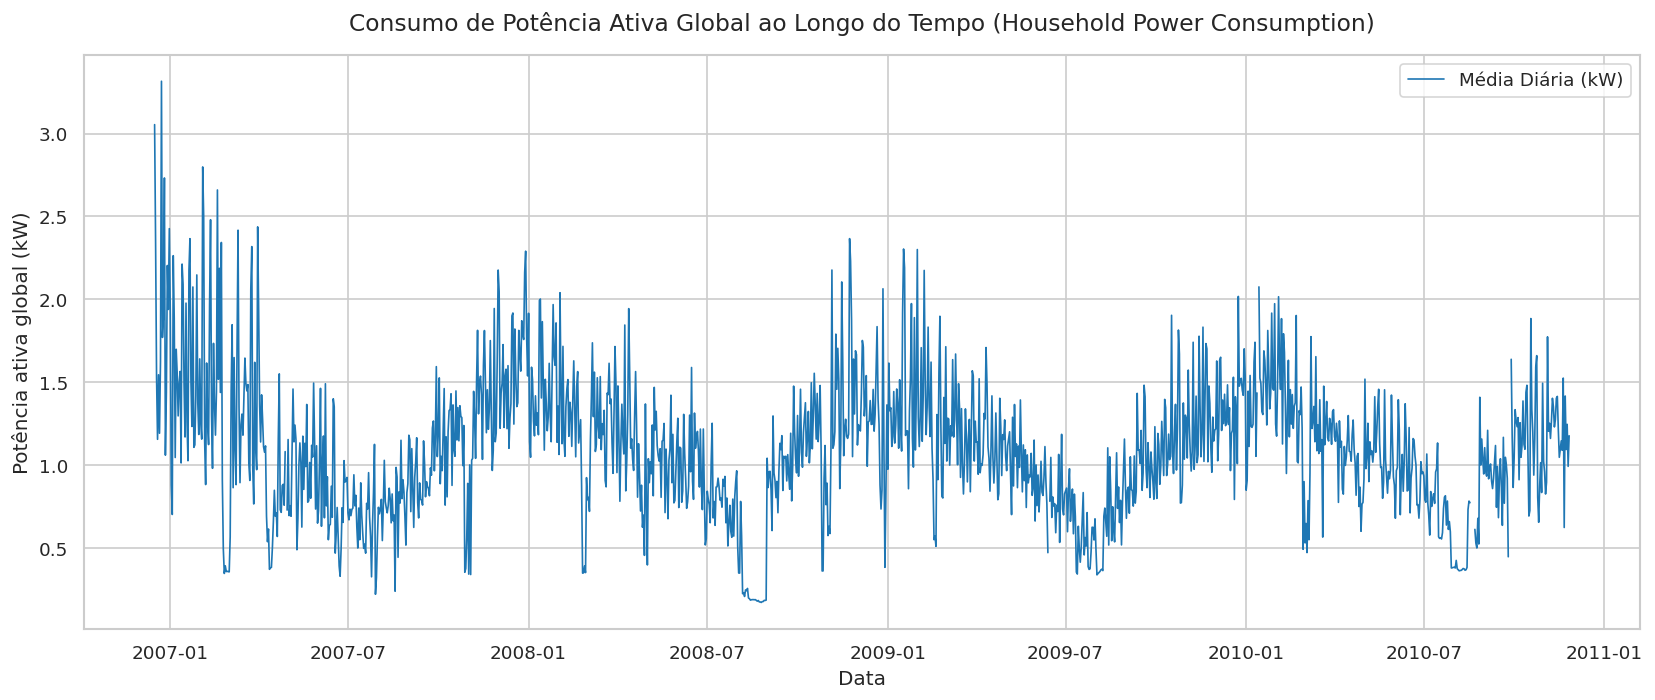

  Shape tratado  : (2075259, 7)
  Intervalo    : 2006-12-16 17:24:00 até 2010-11-26 21:02:00
CPU times: user 25.4 s, sys: 1.57 s, total: 26.9 s
Wall time: 43.3 s


In [3]:
%%time
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from ucimlrepo import fetch_ucirepo

# 1. Download dos dados
print("📥 Baixando UCI Household Power Consumption...")
dataset = fetch_ucirepo(id=235)
df_raw = dataset.data.features.copy()

print(f'   Formato bruto   : {df_raw.shape}')
print(f'   Colunas         : {list(df_raw.columns)}\n')
print(f'   Tipos           : \n{df_raw.dtypes}')

# 2. Tratamento do tipo de dados e índice temporal
df = df_raw.copy()

# Cria coluna datetime e define como índice
df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"], format="%d/%m/%Y %H:%M:%S"
)
df = df.drop(columns=["Date", "Time"]).set_index("Datetime")

# Converte colunas numéricas (forçando coerção para valores inválidos/missing)
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 3. Geração da Saída Gráfica
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

# Reamostragem diária para suavizar o gráfico de alta frequência (minuto a minuto)
df_daily = df["Global_active_power"].resample("D").mean()

plt.plot(
    df_daily.index,
    df_daily.values,
    color="#1f77b4",
    linewidth=1,
    label="Média Diária (kW)",
)
plt.title(
    "Consumo de Potência Ativa Global ao Longo do Tempo (Household Power Consumption)",
    fontsize=14,
    pad=15,
)
plt.xlabel("Data", fontsize=12)
plt.ylabel("Potência ativa global (kW)", fontsize=12)
plt.legend(loc="upper right")
plt.tight_layout()

plt.show()

# Resumo rápido no terminal
print(f"  Formato tratado  : {df.shape}")
print(f"  Intervalo        : {df.index.min()} até {df.index.max()}")

### **Define entradas e saída(s)**

Foi usada uma amostragem **N_SAMPLE = 8000** do total de 2.075.259 amostras (registros).




In [4]:
%%time
# ─── Pré-processamento ────────────────────────────────────────────────────────
df = df_raw.copy()

# Converte colunas numéricas (podem vir como string com '?')
numeric_cols = [
    'Global_active_power', 'Global_reactive_power', 'Voltage',
    'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Remove NaN
df.dropna(inplace=True)
print(f'Registros após limpeza: {len(df):,}')

# Features e target
feature_cols = ['Global_reactive_power','Voltage','Global_intensity',
                'Sub_metering_1','Sub_metering_2','Sub_metering_3']
target_col   = 'Global_active_power'

# Amostragem para HPO ser viável (dataset tem 2075259 registros)
# Usamos sample representativo (manter distribuição original)
N_SAMPLE = 8000

df_sample = df.sample(n=N_SAMPLE, random_state=88).reset_index(drop=True)

X = df_sample[feature_cols].values
y = df_sample[target_col].values

# Normalização
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled  = scaler_X.fit_transform(X)
y_scaled  = scaler_y.fit_transform(y.reshape(-1,1)).ravel()

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

print(f'Features : {feature_cols}')
print(f'Target   : {target_col}')
print(f'Treino   : {X_train.shape[0]} amostras')
print(f'Teste    : {X_test.shape[0]} amostras')

Registros após limpeza: 2,049,280
Features : ['Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
Target   : Global_active_power
Treino   : 6400 amostras
Teste    : 1600 amostras
CPU times: user 8.77 s, sys: 190 ms, total: 8.96 s
Wall time: 17 s


### **Breve análise exploratória de dados**

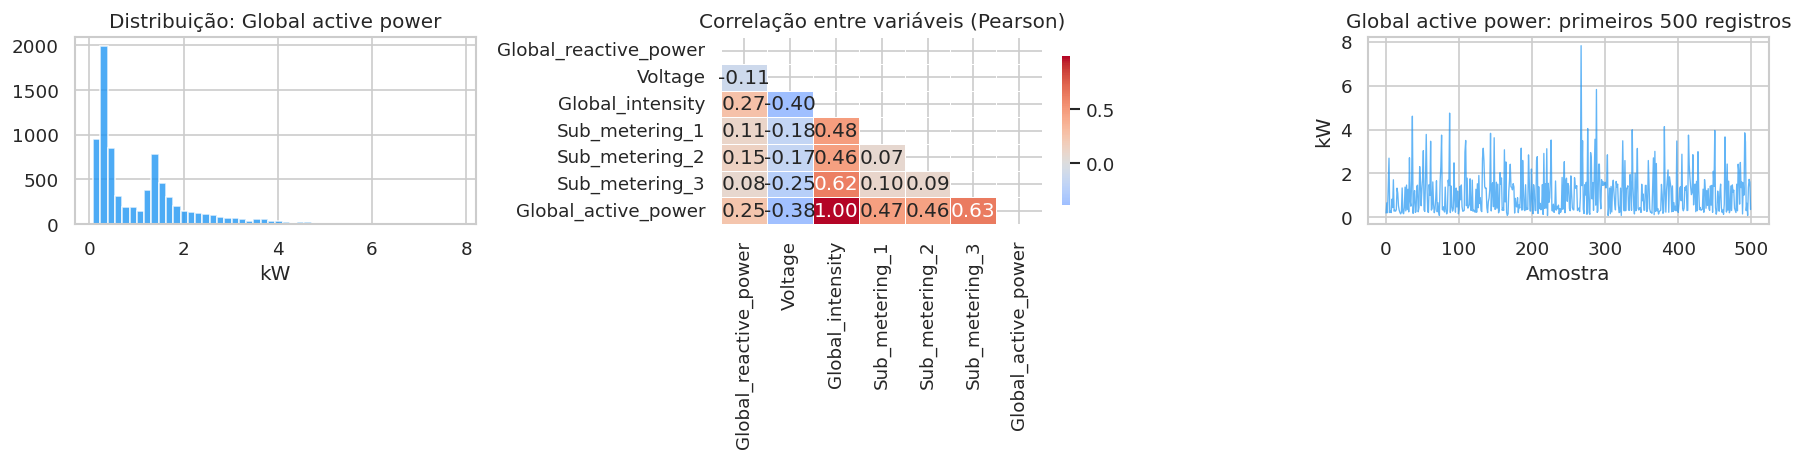


📌 Estatísticas descritivas:


,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Global_active_power
count,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000
mean,0.125,240.877,4.664,1.090,1.332,6.596,1.101
std,0.114,3.194,4.439,6.113,5.960,8.480,1.057
min,0.000,226.140,0.200,0.000,0.000,0.000,0.078
25%,0.048,239.100,1.400,0.000,0.000,0.000,0.312
50%,0.100,240.990,2.800,0.000,0.000,1.000,0.638
75%,0.196,242.850,6.400,0.000,1.000,18.000,1.524
max,1.044,251.780,33.600,78.000,76.000,31.000,7.818


CPU times: user 668 ms, sys: 12.3 ms, total: 680 ms
Wall time: 692 ms


In [ ]:
%%time
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribuição do target
axes[0].hist(df_sample[target_col], bins=50, color=PALETTE[0], alpha=0.8, edgecolor='white')
axes[0].set_title('Distribuição: Global active power')
axes[0].set_xlabel('kW')

# Correlação
corr = df_sample[feature_cols + [target_col]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=axes[1], mask=mask, cmap='coolwarm',
            center=0, annot=True, fmt='.2f', linewidths=0.5,
            cbar_kws={'shrink': 0.8})
axes[1].set_title('Correlação entre variáveis (Pearson)')

# Série temporal (primeiro 1k pontos)
axes[2].plot(df_sample[target_col].values[:500], color=PALETTE[0], alpha=0.7, lw=0.8)
axes[2].set_title('Global active power: primeiros 500 registros')
axes[2].set_xlabel('Amostra')
axes[2].set_ylabel('kW')

#plt.suptitle('📊 EDA — UCI Household Power Consumption', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n📌 Estatísticas descritivas:')
display(df_sample[feature_cols + [target_col]].describe().round(3))

## 📚 **Fundamentação teórica**

### <font color="blue">**O problema formal de otimização de hiperparâmetros (HPO)**</font>

Dado um espaço de hiperparâmetros $\Lambda$ e um algoritmo de aprendizado $\mathcal{A}$, deseja-se:

$$\lambda^* = \arg\min_{\lambda \in \Lambda} \; \mathcal{L}\!\left(\mathcal{A}_\lambda, \mathcal{D}_{\text{val}}\right)$$

onde $\mathcal{L}$ é uma função de perda (por exemplo: RMSE, acurácia, ...) e $\mathcal{D}_{\text{val}}$ é um conjunto de validação.

---

### <font color="blue">**Características que tornam HPO uma tarefa complexa**</font>

| Característica | Impacto |
|---------------|--------|
| Alta dimensionalidade | Espaço exponencialmente grande |
| Interações não-lineares | taxa de aprendizado ($\eta$) e o número de estimadores/árvores ($n_{est}$) podem interagir fortemente |
| Custo de avaliação | Cada trial = treinamento completo |
| Espaço misto | Discretos + Contínuos + Categóricos |
| Ruído da validação | validação cruzada introduz variância na estimativa |

---

### <font color="blue">**Compromisso viés-variância nos hiperparâmetros**</font>

$$\text{Erro}_{\text{gen}} = \underbrace{\text{Viés}^2}_{\text{subajuste}} + \underbrace{\text{Variância}}_{\text{sobreajuste}} + \varepsilon_{\text{irredutível}}$$

- **Aumentar capacidade** (ex: `max_depth` alto, `n_estimators` alto) → ↓ Viés, ↑ Variância
- **Regularização** (ex: `min_samples_leaf`, `alpha`) → ↑ Viés, ↓ Variância

---

### <font color="blue">**Breve panorama das abordagens**</font>

```
ABORDAGEM            MÉTODO                 BIBLIOTECA
─────────────────────────────────────────────────────────
Exaustiva        →  Busca em gride          sklearn
Estocástica      →  Busca aleatória         sklearn
Model-Based/GP   →  Otimização Bayesiana    skopt, bayes_opt
Model-Based/TPE  →  TPE Sampler             Optuna, Hyperopt
Evolutiva        →  GA, DE, PSO             DEAP, scipy
```

### **Superfície HPO e compromisso viés-variância**

A **superfície de desempenho do HPO** (*Hyperparameter Optimization*) é a representação geométrica de como a métrica de avaliação do modelo (tais como acurácia, F1-score ou erro quadrático médio) varia à medida que navegamos pelas diferentes combinações de hiperparâmetros no espaço de busca.

Trata-se de uma superfície tipicamente não convexa, repleta de picos, vales e platôs, o que torna a busca por configurações ótimas um problema desafiador.

No centro da navegação por essa superfície está o **compromisso entre viés e variância** (*bias-variance tradeoff*). A escolha de cada hiperparâmetro desloca diretamente a posição do modelo nesse espectro, definindo a forma da superfície e a capacidade de generalização da solução:

* **Região de Subajuste (*underfitting* / alto viés):** Ocorre quando os hiperparâmetros restringem excessivamente a capacidade de aprendizado do modelo — por exemplo, ao definir uma profundidade máxima muito baixa em árvores de decisão, aplicar regularização $L_1/L_2$ demasiadamente alta ou utilizar uma taxa de aprendizado (*learning rate*) muito pequena. Na superfície de HPO, essa região é caracterizada por um desempenho insatisfatório e estagnado tanto no conjunto de treino quanto no de validação.

* **Região de Sobreajuste (*overfitting* / alta variância):** Ocorre quando as configurações conferem capacidade excessiva ao modelo — como redes neurais extremamente profundas sem técnicas de *dropout*, ou um número elevado de estimadores sem limitação de profundidade. O modelo passa a memorizar o ruído dos dados de treino. Na superfície de HPO, isso se manifesta como uma grande discrepância entre a métrica de treino (que atinge picos de desempenho) e a métrica de validação (que cai abruptamente).

---

###<font color="blue">**O papel do HPO no equilíbrio**</font>

O objetivo primário do HPO não é simplesmente encontrar um ponto de máximo global absoluto sobre os dados de treino, mas sim **mapear e localizar a região da superfície que minimiza o erro total de generalização**.

Para evitar ser enganado por "falsos picos" de alta variância, a avaliação na superfície de HPO deve sempre utilizar estratégias robustas de validação (como *K-Fold Cross-Validation*). Assim, a busca por hiperparâmetros atua como um mecanismo guiado para selecionar o ponto exato de equilíbrio ótimo entre a rigidez do modelo (viés) e sua sensibilidade ao ruído (variância).

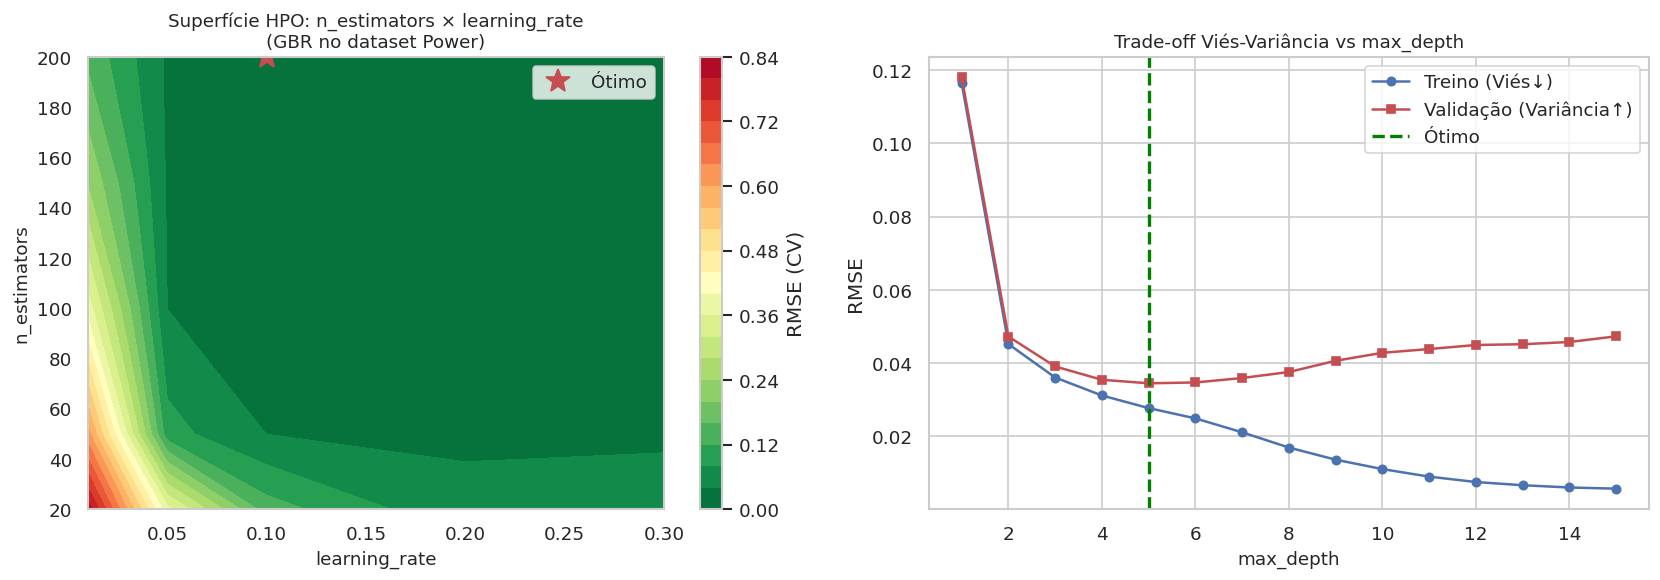

CPU times: user 1min 49s, sys: 131 ms, total: 1min 49s
Wall time: 2min 6s


In [ ]:
%%time
from sklearn.ensemble import GradientBoostingRegressor

# Superfície 2D: n_estimators x max_depth
n_vals  = [20, 50, 100, 150, 200]
lr_vals = [0.01, 0.05, 0.1, 0.2, 0.3]
scores_map = np.zeros((len(n_vals), len(lr_vals)))

for i, n in enumerate(n_vals):
    for j, lr in enumerate(lr_vals):
        model = GradientBoostingRegressor(n_estimators=n, learning_rate=lr,
                                          max_depth=3, random_state=42)
        cv_scores = cross_val_score(model, X_train, y_train, cv=3,
                                    scoring='neg_root_mean_squared_error')
        scores_map[i, j] = -cv_scores.mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Superfície HPO
im = axes[0].contourf(lr_vals, n_vals, scores_map, levels=20, cmap='RdYlGn_r')
plt.colorbar(im, ax=axes[0], label='RMSE (CV)')
axes[0].set_xlabel('learning_rate', fontsize=11)
axes[0].set_ylabel('n_estimators', fontsize=11)
axes[0].set_title('Superfície HPO: n_estimators × learning_rate\n(GBR no dataset Power)', fontsize=11)
idx_min = np.unravel_index(np.argmin(scores_map), scores_map.shape)
axes[0].plot(lr_vals[idx_min[1]], n_vals[idx_min[0]], 'r*', ms=15, label='Ótimo')
axes[0].legend()

# Bias-Variance
depths = np.arange(1, 16)
train_err, val_err = [], []
for d in depths:
    m = GradientBoostingRegressor(max_depth=int(d), n_estimators=50, random_state=88)
    m.fit(X_train, y_train)
    train_err.append(mean_squared_error(y_train, m.predict(X_train))**0.5)
    val_err.append(-cross_val_score(m, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error').mean())

axes[1].plot(depths, train_err, 'b-o', label='Treino (Viés↓)', ms=5)
axes[1].plot(depths, val_err,   'r-s', label='Validação (Variância↑)', ms=5)
axes[1].axvline(depths[np.argmin(val_err)], color='green', ls='--', lw=2, label='Ótimo')
axes[1].set_xlabel('max_depth', fontsize=11)
axes[1].set_ylabel('RMSE')
axes[1].set_title('Trade-off Viés-Variância vs max_depth', fontsize=11)
axes[1].legend()

#plt.subtitle('📊 Fundamentos de HPO', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔎 **Métodos clássicos: Busca em grade e busca aleatória**

### <font color="blue">**Busca em grade (*grid search*) — Busca exaustiva**</font>


Define uma grade de valores discretos e avalia **todas** as $N_1 \times N_2 \times \ldots \times N_k$ combinações.

**Complexidade:** exponencial no número de hiperparâmetros.

---

### <font color="blue">**Busca aleatória (*random search*)**</font>

Amostra aleatoriamente do espaço de hiperparâmetros.

Se apenas uma fração dos hiperparâmetros importa (*esparsidade efetiva*), Random Search encontra soluções com menos avaliações que a busca em grade.

In [ ]:
%%time

# ─── Métricas de Avaliação ────────────────────────────────────────────────────
def compute_metrics(y_true, y_pred, label=''):
    rmse = mean_squared_error(y_true, y_pred)**0.5
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    if label:
        print(f'  [{label}] RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}')
    return {'rmse': rmse, 'mae': mae, 'r2': r2}

# Registro global de resultados
RESULTS = []   # lista de dicts: método, cv_rmse, test_rmse, test_mae, test_r2, tempo, n_evals

# ─── Espaço de Hiperparâmetros ────────────────────────────────────────────────
param_grid = {
    'n_estimators' : [25, 50, 100],
    'max_depth'    : [2, 3, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample'    : [0.7, 1.0]
}
total_combos = 3*3*3*2
print(f'Total de combinações Grid: {total_combos}')

gbr = GradientBoostingRegressor(random_state=42)
cv  = KFold(n_splits=5, shuffle=True, random_state=42)

# ── Grid Search ───────────────────────────────────────────────────────────────
print('\n🔲 Busca em grade ...')
t0 = time.perf_counter()
grid_cv = GridSearchCV(gbr, param_grid, cv=cv,
                       scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=0)
grid_cv.fit(X_train, y_train)
t_grid = time.perf_counter() - t0

y_pred_grid = grid_cv.best_estimator_.predict(X_test)
m_grid = compute_metrics(y_test, y_pred_grid, 'Grid')
RESULTS.append({'Método':'Grid Search', 'CV RMSE': -grid_cv.best_score_,
                **m_grid, 'Tempo(s)': t_grid, 'N evals': total_combos})
print(f'   Tempo: {t_grid:.1f}s | Best params: {grid_cv.best_params_}')

# ── Random Search ─────────────────────────────────────────────────────────────
print('\n🎲 Busca aleatória (30 tentativas) ...')
t0 = time.perf_counter()
rand_cv = RandomizedSearchCV(gbr, param_grid, n_iter=30, cv=cv,
                              scoring='neg_root_mean_squared_error',
                              random_state=88, n_jobs=-1, verbose=0)
rand_cv.fit(X_train, y_train)
t_rand = time.perf_counter() - t0

y_pred_rand = rand_cv.best_estimator_.predict(X_test)
m_rand = compute_metrics(y_test, y_pred_rand, 'Random')
RESULTS.append({'Método':'Random Search', 'CV RMSE': -rand_cv.best_score_,
                **m_rand, 'Tempo(s)': t_rand, 'N evals': 30})
print(f'   Tempo: {t_rand:.1f}s | Best params: {rand_cv.best_params_}')

Total de combinações Grid: 54

🔲 Busca em grade ...
  [Grid] RMSE=0.0323  MAE=0.0194  R²=0.9990
   Tempo: 88.0s | Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.7}

🎲 Busca aleatória (30 tentativas) ...
  [Random] RMSE=0.0343  MAE=0.0201  R²=0.9988
   Tempo: 42.9s | Best params: {'subsample': 0.7, 'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.2}
CPU times: user 2.57 s, sys: 186 ms, total: 2.75 s
Wall time: 2min 10s


### **Convergência: Busca em grade e busca aleatória**

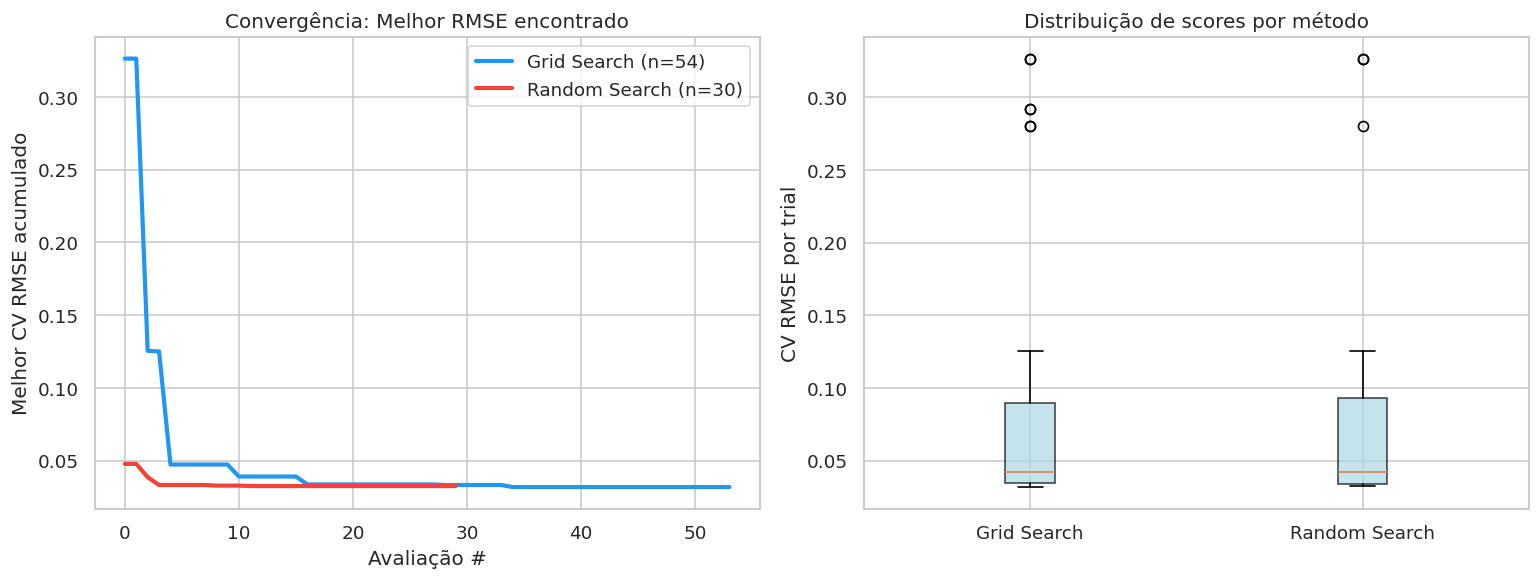

CPU times: user 304 ms, sys: 2.99 ms, total: 307 ms
Wall time: 306 ms


In [ ]:
%%time
grid_scores   = -grid_cv.cv_results_['mean_test_score']
random_scores = -rand_cv.cv_results_['mean_test_score']

best_grid   = [min(grid_scores[:i+1]) for i in range(len(grid_scores))]
best_random = [min(random_scores[:i+1]) for i in range(len(random_scores))]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(best_grid,   color=PALETTE[0], lw=2.5, label=f'Grid Search (n={len(grid_scores)})')
axes[0].plot(best_random, color=PALETTE[1], lw=2.5, label=f'Random Search (n={len(random_scores)})')
axes[0].set_xlabel('Avaliação #')
axes[0].set_ylabel('Melhor CV RMSE acumulado')
axes[0].set_title('Convergência: Melhor RMSE encontrado')
axes[0].legend()

axes[1].boxplot([grid_scores, random_scores],
                labels=['Grid Search','Random Search'],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7))
axes[1].set_ylabel('CV RMSE por trial')
axes[1].set_title('Distribuição de scores por método')

#plt.suptitle('📊 Grid Search vs Random Search — Dataset UCI Power', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔬 **Processo Gaussiano: Fundamentos**

Um **Processo Gaussiano (Gaussian Process, GP)** é uma distribuição sobre funções tal que, para qualquer conjunto finito de pontos $\{x_1, \ldots, x_n\}$, os valores $\{f(x_1), \ldots, f(x_n)\}$ seguem uma distribuição Gaussiana multivariada:

$$f(\mathbf{x}) \sim \mathcal{GP}\big(m(\mathbf{x}),\; k(\mathbf{x}, \mathbf{x}')\big)$$

onde
- $m(\mathbf{x}) = \mathbb{E}[f(\mathbf{x})]$ — **função de média** (frequentemente zero)
- $k(\mathbf{x}, \mathbf{x}') = \text{Cov}(f(\mathbf{x}), f(\mathbf{x}'))$ — **função kernel** (codifica suavidade, escala)

---

### <font color="blue">**Passos da regressão GP**</font>

```
DADO: Observações D = {(x₁,y₁), ..., (xₙ,yₙ)} com yᵢ = f(xᵢ) + εᵢ, εᵢ ~ N(0,σ²ₙ)

PASSO 1 — A priori:
  f ~ GP(0, k(x,x'))   →   [f₁,...,fₙ] ~ N(0, K)
  onde Kᵢⱼ = k(xᵢ, xⱼ)

PASSO 2 — Verossimilhança (likelihood):
  y | f ~ N(f, σ²ₙI)

PASSO 3 — Posterior (distribuição preditiva em x*):
  f* | D, x* ~ N(μ*, σ*²)
  
  μ*(x*)  = k*ᵀ (K + σ²ₙI)⁻¹ y
  σ*²(x*) = k** - k*ᵀ (K + σ²ₙI)⁻¹ k*
  
  onde k* = [k(x*,x₁), ..., k(x*,xₙ)]ᵀ,  k** = k(x*,x*)

PASSO 4 — Atualização sequencial:
  Adiciona (x_novo, y_novo) → recalcula posterior → maximiza acquisition function
```

### <font color="blue">**Kernels mais utilizados**</font>

**RBF** (Squared Exponential)  
$\exp\!\left(-\dfrac{\|x-x'\|^2}{2\ell^2}\right)$  
*Infinitamente diferenciável*

---

**Matérn 5/2**  
$\left(1 + \dfrac{\sqrt{5}r}{\ell} + \dfrac{5r^2}{3\ell^2}\right)e^{-\frac{\sqrt{5}r}{\ell}}$  
*Mais realista para HPO*

---

**Periódico**  
$\exp\!\left(-\dfrac{2\sin^2(\pi r/p)}{\ell^2}\right)$  
*Dados sazonais*

---

### <font color="blue">**Função de aquisição**</font>

**EI** (Expected Improvement)  
$\mathbb{E}[\max(f^+ - f(x), 0)]$  
*Balanceado — padrão*

---

**UCB** (Upper Confidence Bound)  
$\mu(x) + \kappa\,\sigma(x)$  
*$\kappa$ controla exploração*

---

**PI** (Probability of Improvement)  
$\Phi\!\left(\dfrac{\mu(x)-f^+-\xi}{\sigma(x)}\right)$  
*Mais gulosa (greedy)*

---

**LCB** (Lower Confidence Bound)  
$\mu(x) - \kappa\,\sigma(x)$  
*Para minimização*

---

**Referências**

**Rasmussen, C. E., Williams, C. K. I. (2006).** Gaussian Processes for Machine Learning. MIT Press. http://www.gaussianprocess.org/gpml/

**Frazier, P. I. (2018).** A Tutorial on Bayesian Optimization. arXiv preprint arXiv:1807.02811. https://arxiv.org/abs/1807.02811

**Snoek, J., Larochelle, H., Adams, R. P. (2012).** Practical Bayesian Optimization of Machine Learning Algorithms. Advances in Neural Information Processing Systems (NeurIPS 25), 2951–2959. https://proceedings.neurips.cc/paper/2012/hash/05371771c58309e3384a9cb226bfe38d-Abstract.html

### **Demonstração do Processo Gaussiano: A priori → A posteriori → aquisição**

**Distribuição a priori**:
Representa o conhecimento ou premissas iniciais sobre a função desconhecida $f(x)$ antes da observação de dados.

Define a média (geralmente assumida como zero) e a covariância entre pontos via função de covariância ou kernel $k(x, x')$, que determina propriedades como suavidade e amplitude.

---

**Verossimilhança (*likelihood*)**:
Modela a probabilidade dos dados observados $y$ dado o estado da função $f$, frequentemente assumindo um ruído Gaussiano aditivo com variância $\sigma_n^2$:$$y \mid f \sim \mathcal{N}(f, \sigma_n^2 \mathbf{I})$$

---

**Distribuição a posteriori**:
Obtida pela aplicação do Regra de Bayes, combinando a distribuição a priori com as observações coletadas. Ajusta a média para interpolar/aproximar os dados reais e reduz a incerteza (variância) nas regiões próximas aos pontos amostrados.

---

**Função de aquisição (*acquisition function*)**:
Utiliza a média e a variância fornecidas pela distribuição a posteriori para guiar a escolha do próximo ponto a ser avaliado.

Equilibra a exploração de regiões com alta incerteza (*exploration*) e a exploração de regiões com valores ótimos esperados (*exploitation*), como nos algoritmos de melhoria esperada (*Expected Improvement*, EI) ou Limite Superior de Confiança (*Upper Confidence Bound*, UCB).


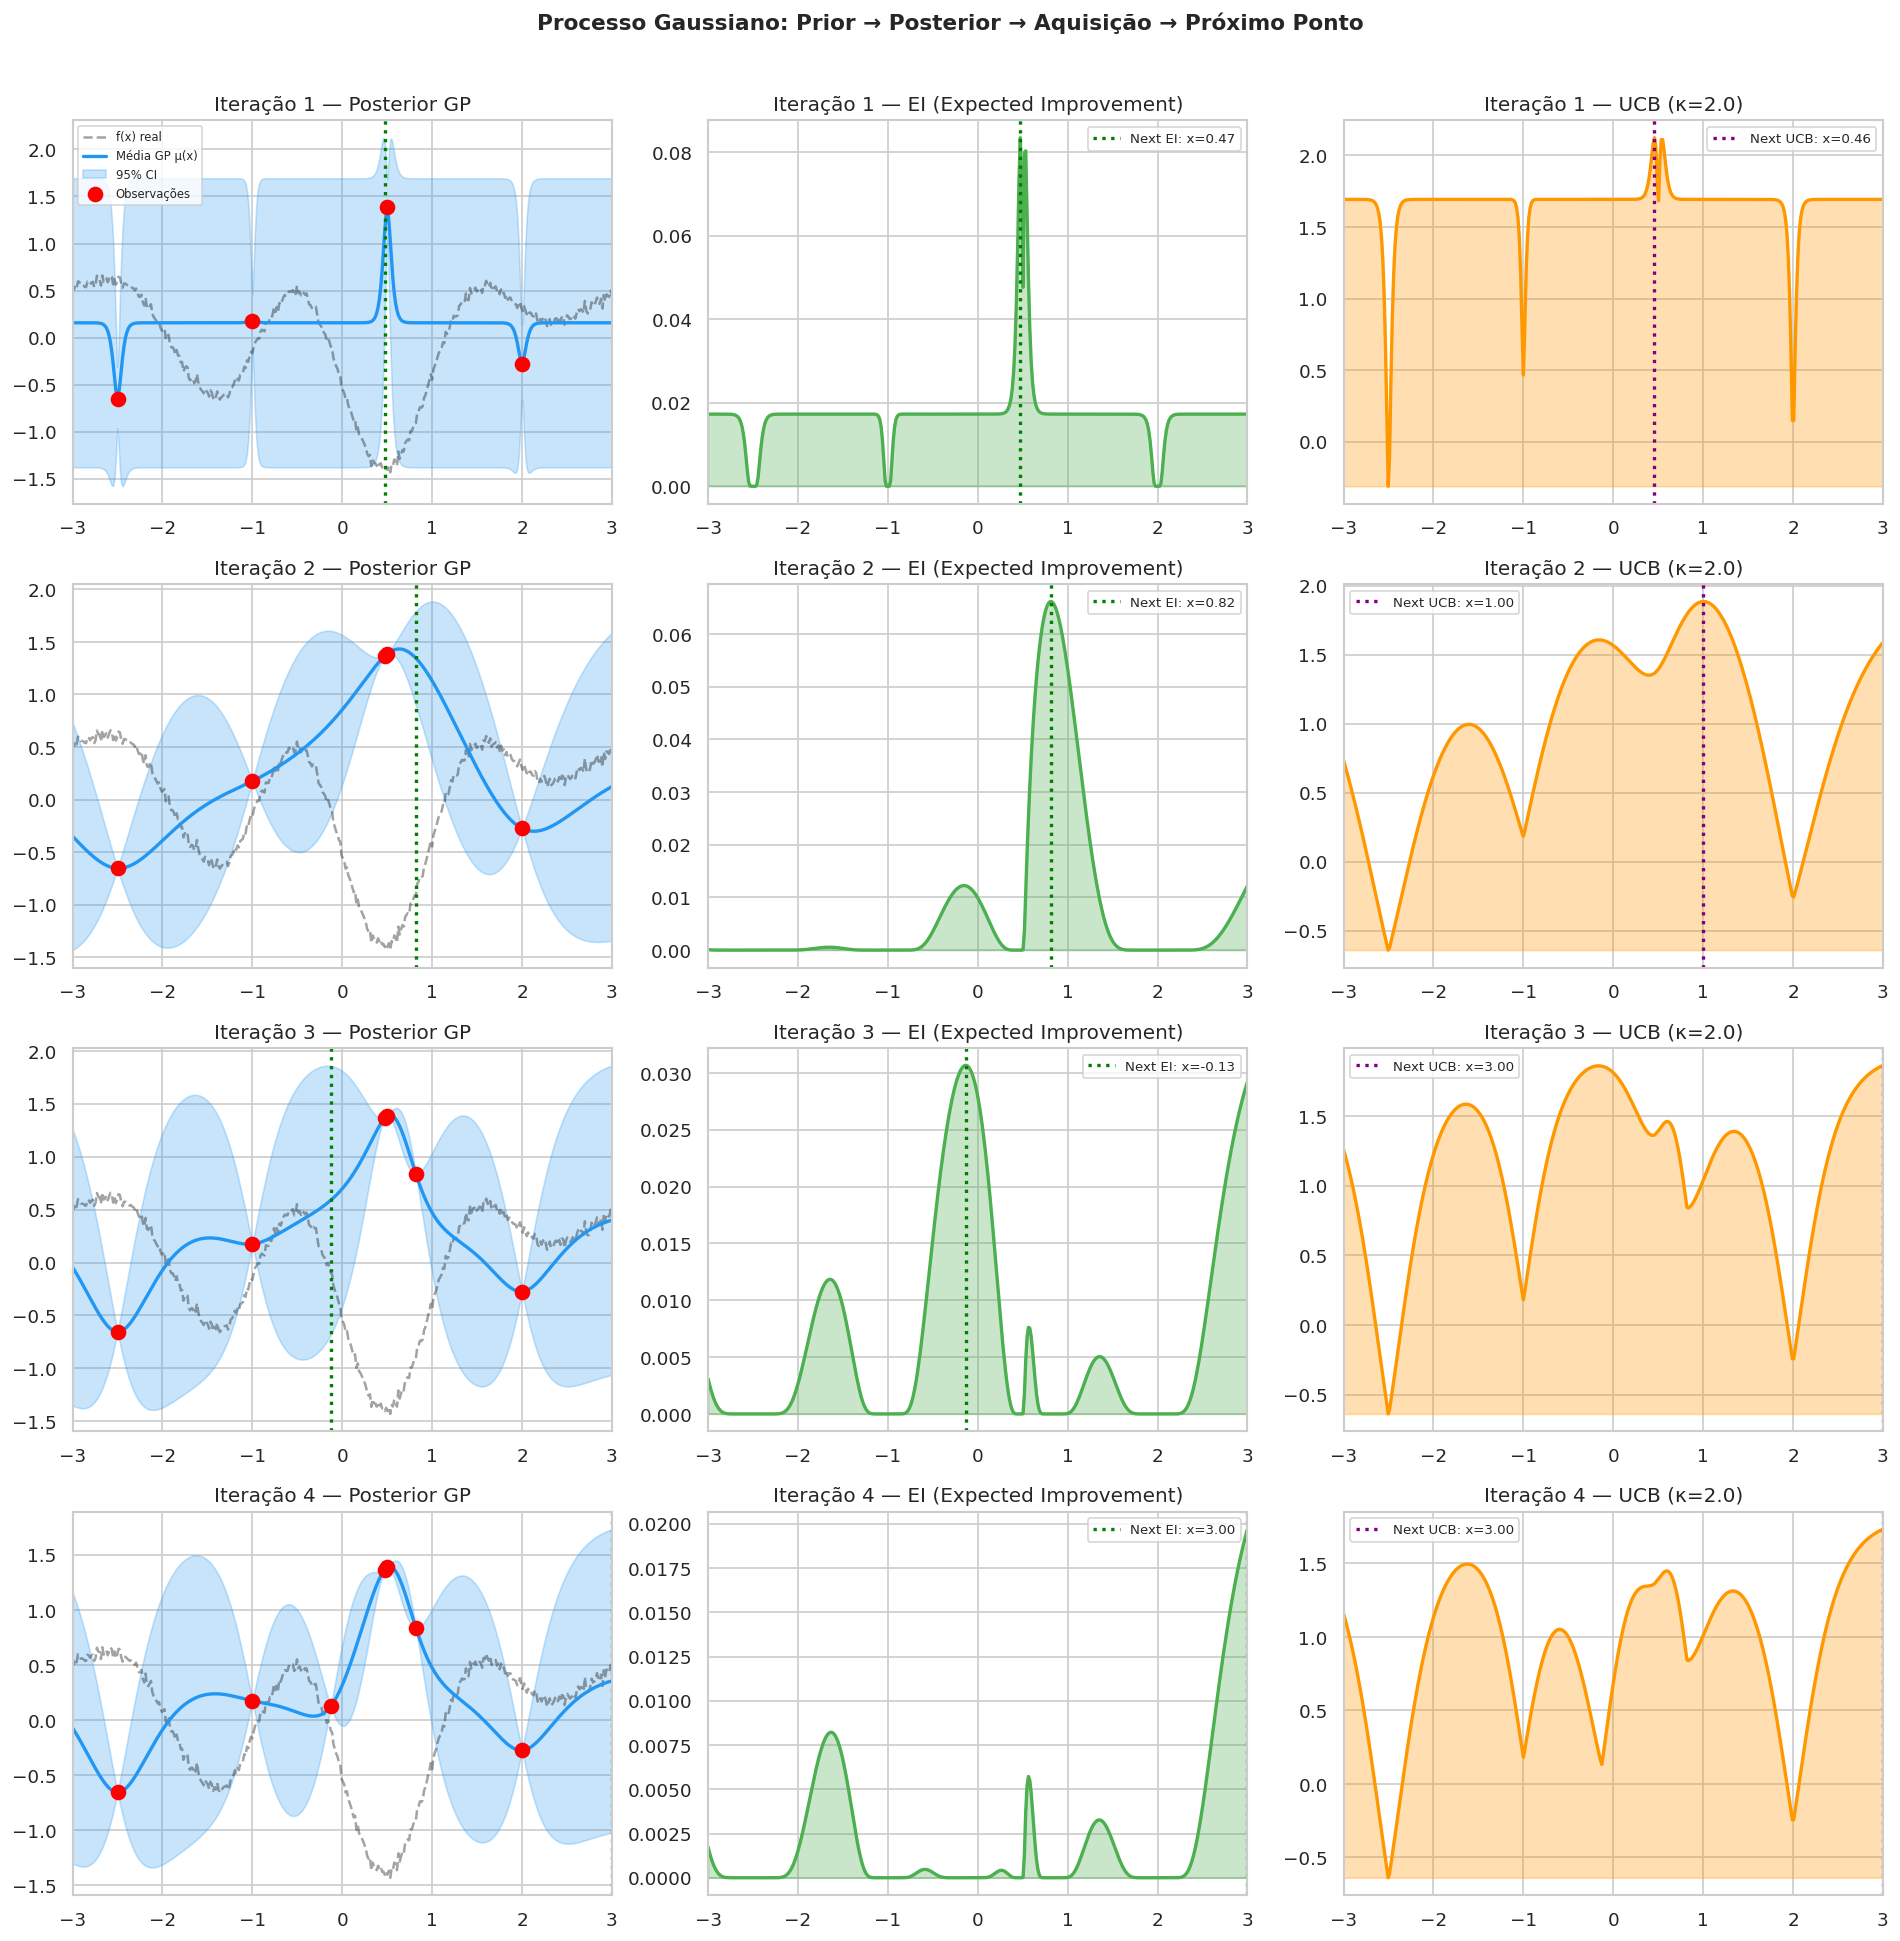

✅ GP demo: após 8 avaliações, mínimo em x = 0.500
CPU times: user 5.92 s, sys: 28.5 ms, total: 5.95 s
Wall time: 6.45 s


In [ ]:
%%time

def neg_rmse_objective(x_scalar):
    """Função objetivo sintética 1D (simula CV score vs hiperparâmetro log-lr)."""
    x = np.atleast_1d(x_scalar)
    return -(np.sin(3*x) * np.exp(-x**2/4) + 0.5*np.cos(x) + np.random.normal(0, 0.03, x.shape))

def acquisition_EI(X_cand, X_obs, y_obs, gp, xi=0.01):
    mu, sigma = gp.predict(X_cand, return_std=True)
    f_best = np.min(y_obs)
    imp = f_best - mu - xi
    Z   = imp / (sigma + 1e-9)
    ei  = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma < 1e-10] = 0.0
    return ei

def acquisition_UCB(X_cand, gp, kappa=2.0):
    mu, sigma = gp.predict(X_cand, return_std=True)
    return -(mu - kappa * sigma)  # LCB convertido para maximização

# Domínio
X_domain = np.linspace(-3, 3, 400).reshape(-1, 1)
y_true_domain = neg_rmse_objective(X_domain.ravel()) * (-1)  # para visualização

# Pontos iniciais
X_init = np.array([-2.5, -1.0, 0.5, 2.0]).reshape(-1, 1)
y_init = neg_rmse_objective(X_init.ravel())

kernel = ConstantKernel(1.0) * Matern(length_scale=1.0, nu=2.5) + WhiteKernel(noise_level=0.01)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, normalize_y=True)

n_iters = 4
X_obs = X_init.copy()
y_obs = y_init.copy()

fig, axes = plt.subplots(n_iters, 3, figsize=(16, 4*n_iters))
fig.suptitle('Processo Gaussiano: Prior → Posterior → Aquisição → Próximo Ponto',
             fontsize=13, fontweight='bold', y=1.01)

for i in range(n_iters):
    gp.fit(X_obs, y_obs)
    mu, sigma = gp.predict(X_domain, return_std=True)
    ei  = acquisition_EI(X_domain, X_obs, y_obs, gp)
    ucb = acquisition_UCB(X_domain, gp)
    next_x_ei  = X_domain[np.argmax(ei)]
    next_x_ucb = X_domain[np.argmax(ucb)]

    # Col 0: Posterior GP
    ax = axes[i, 0]
    ax.plot(X_domain, -y_true_domain, 'k--', lw=1.5, alpha=0.4, label='f(x) real')
    ax.plot(X_domain, -mu, color=PALETTE[0], lw=2, label='Média GP μ(x)')
    ax.fill_between(X_domain.ravel(), -mu - 2*sigma, -mu + 2*sigma,
                    alpha=0.25, color=PALETTE[0], label='95% CI')
    ax.scatter(X_obs, -y_obs, c='red', zorder=5, s=70, label='Observações')
    ax.axvline(next_x_ei[0], color='green', ls=':', lw=2)
    ax.set_title(f'Iteração {i+1} — Posterior GP')
    if i == 0: ax.legend(fontsize=7)
    ax.set_xlim(-3, 3)

    # Col 1: EI
    ax2 = axes[i, 1]
    ax2.plot(X_domain, ei, color=PALETTE[2], lw=2)
    ax2.fill_between(X_domain.ravel(), 0, ei, alpha=0.3, color=PALETTE[2])
    ax2.axvline(next_x_ei[0], color='green', ls=':', lw=2,
                label=f'Next EI: x={next_x_ei[0]:.2f}')
    ax2.set_title(f'Iteração {i+1} — EI (Expected Improvement)')
    ax2.legend(fontsize=8)
    ax2.set_xlim(-3, 3)

    # Col 2: UCB
    ax3 = axes[i, 2]
    ax3.plot(X_domain, ucb, color=PALETTE[3], lw=2)
    ax3.fill_between(X_domain.ravel(), ucb.min(), ucb, alpha=0.3, color=PALETTE[3])
    ax3.axvline(next_x_ucb[0], color='purple', ls=':', lw=2,
                label=f'Next UCB: x={next_x_ucb[0]:.2f}')
    ax3.set_title(f'Iteração {i+1} — UCB (κ=2.0)')
    ax3.legend(fontsize=8)
    ax3.set_xlim(-3, 3)

    # Adiciona novo ponto (usando EI)
    new_y = neg_rmse_objective(np.array([next_x_ei[0]]))
    X_obs = np.vstack([X_obs, next_x_ei])
    y_obs = np.append(y_obs, new_y)

plt.tight_layout()
plt.show()
print(f'✅ GP demo: após {len(X_obs)} avaliações, mínimo em x = {X_obs[np.argmin(y_obs)][0]:.3f}')

### **Animação do Processo Gaussiano**

In [ ]:
%%time
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, WhiteKernel
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Definindo paleta de cores para consistência
PALETTE = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']

def neg_rmse_objective(x_scalar):
    """Função objetivo sintética 1D (simula CV score vs hiperparâmetro log-lr)."""
    x = np.atleast_1d(x_scalar)
    return -(np.sin(3*x) * np.exp(-x**2/4) + 0.5*np.cos(x) + np.random.normal(0, 0.03, x.shape))

def acquisition_EI(X_cand, X_obs, y_obs, gp, xi=0.01):
    mu, sigma = gp.predict(X_cand, return_std=True)
    f_best = np.min(y_obs)
    imp = f_best - mu - xi
    Z   = imp / (sigma + 1e-9)
    ei  = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma < 1e-10] = 0.0
    return ei

def acquisition_UCB(X_cand, gp, kappa=2.0):
    mu, sigma = gp.predict(X_cand, return_std=True)
    return -(mu - kappa * sigma)  # LCB convertido para maximização

# Domínio
X_domain = np.linspace(-3, 3, 400).reshape(-1, 1)
# Função real sem ruído apenas para referência do plot
y_true_clean = -(np.sin(3*X_domain.ravel()) * np.exp(-X_domain.ravel()**2/4) + 0.5*np.cos(X_domain.ravel()))

# Pontos iniciais
X_init = np.array([-2.5, -1.0, 0.5, 2.0]).reshape(-1, 1)
y_init = neg_rmse_objective(X_init.ravel())

# Configuração do Modelo GP
kernel = ConstantKernel(1.0) * Matern(length_scale=1.0, nu=2.5) + WhiteKernel(noise_level=0.01)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, normalize_y=True)

# Armazenamento do histórico para a animação
n_iters = 8
history = []
X_obs = X_init.copy()
y_obs = y_init.copy()

for i in range(n_iters):
    gp.fit(X_obs, y_obs)
    mu, sigma = gp.predict(X_domain, return_std=True)
    ei  = acquisition_EI(X_domain, X_obs, y_obs, gp)
    ucb = acquisition_UCB(X_domain, gp)
    next_x_ei  = X_domain[np.argmax(ei)]
    next_x_ucb = X_domain[np.argmax(ucb)]

    # Salva o estado atual
    history.append({
        'iter': i + 1,
        'X_obs': X_obs.copy(),
        'y_obs': y_obs.copy(),
        'mu': mu,
        'sigma': sigma,
        'ei': ei,
        'ucb': ucb,
        'next_x_ei': next_x_ei[0],
        'next_x_ucb': next_x_ucb[0]
    })

    # Atualiza observações usando o próximo ponto sugerido por EI
    new_y = neg_rmse_objective(np.array([next_x_ei[0]]))
    X_obs = np.vstack([X_obs, next_x_ei])
    y_obs = np.append(y_obs, new_y)

# Configuração da Figura para Animação
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Otimização Bayesiana: Processo Gaussiano em tempo real', fontsize=13, fontweight='bold')

def update(frame):
    state = history[frame]

    ax1.clear()
    ax2.clear()
    ax3.clear()

    # Coluna 1: Posterior GP
    ax1.plot(X_domain, y_true_clean, 'k--', lw=1.5, alpha=0.4, label='f(x) real')
    ax1.plot(X_domain, -state['mu'], color=PALETTE[0], lw=2, label='Média GP μ(x)')
    ax1.fill_between(X_domain.ravel(), -state['mu'] - 2*state['sigma'], -state['mu'] + 2*state['sigma'],
                     alpha=0.25, color=PALETTE[0], label='95% CI')
    ax1.scatter(state['X_obs'], -state['y_obs'], c='red', zorder=5, s=70, label='Observações')
    ax1.axvline(state['next_x_ei'], color='green', ls=':', lw=2)
    ax1.set_title(f'Iteração {state["iter"]} — Posterior GP')
    ax1.legend(fontsize=8, loc='upper left')
    ax1.set_xlim(-3, 3)

    # Coluna 2: Expected Improvement (EI)
    ax2.plot(X_domain, state['ei'], color=PALETTE[2], lw=2)
    ax2.fill_between(X_domain.ravel(), 0, state['ei'], alpha=0.3, color=PALETTE[2])
    ax2.axvline(state['next_x_ei'], color='green', ls=':', lw=2,
                label=f'Next EI: x={state["next_x_ei"]:.2f}')
    ax2.set_title(f'Iteração {state["iter"]} — EI (Expected Improvement)')
    ax2.legend(fontsize=8, loc='upper right')
    ax2.set_xlim(-3, 3)

    # Coluna 3: Upper Confidence Bound (UCB)
    ax3.plot(X_domain, state['ucb'], color=PALETTE[3], lw=2)
    ax3.fill_between(X_domain.ravel(), state['ucb'].min(), state['ucb'], alpha=0.3, color=PALETTE[3])
    ax3.axvline(state['next_x_ucb'], color='purple', ls=':', lw=2,
                label=f'Next UCB: x={state["next_x_ucb"]:.2f}')
    ax3.set_title(f'Iteração {state["iter"]} — UCB (κ=2.0)')
    ax3.legend(fontsize=8, loc='upper right')
    ax3.set_xlim(-3, 3)

    plt.tight_layout()

# Criação da animação
anim = FuncAnimation(fig, update, frames=len(history), interval=1500, repeat=True)
plt.close()  # Impede a renderização estática do último frame

# Exibe a animação interativa no notebook
HTML(anim.to_jshtml())

CPU times: user 10.4 s, sys: 68.1 ms, total: 10.5 s
Wall time: 11.4 s


<Figure size 768x576 with 0 Axes>

## 🧠 **Otimização Bayesiana**

Neste módulo **6 abordagens** de otimização Bayesiana são aplicadas ao conjunto de dados (UCI Power Consumption).

O modelo alvo é o [**GradientBoostingRegressor**](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html) e a métrica principal é a raiz do erro médio quadrático com 5-partições de validação curazada - **RMSE (CV-5)**.

O **`GradientBoostingRegressor`** é um algoritmo de aprendizado de máquina supervisionado para problemas de **regressão** (previsão de valores contínuos).

Ele combina múltiplos modelos fracos geralmente **árvores de decisão** simples de forma sequencial.

A cada etapa, uma nova árvore é treinada para **corrigir os erros (resíduos)** cometidos pelas árvores anteriores, utilizando o algoritmo de descida de encosta (*gradient descent*) para minimizar a função de perda total.

---

### <font color="blue">**Espaço de hiperparâmetros unificado**</font>

```
n_estimators  : [50, 500]      (inteiro)
max_depth     : [2, 8]         (inteiro)
learning_rate : [0.01, 0.3]   (contínuo, log-uniform)
subsample     : [0.6, 1.0]    (contínuo)
min_samples_leaf: [1, 20]     (inteiro)
```

---

### <font color="blue">**Diagrama de fluxo - Otimização Bayesiana**</font>

```
Avaliações iniciais (aleatórias)
│
▼
Ajustar modelo surrogado
(GP ou Tree-structured Parzen Estimator - TPE)
│
▼
Maximizar a função de aquisição
│
▼
Obter o próximo ponto candidato → θ_próximo
│
▼
Avaliar a função objetivo
f(θ_próximo) = treinar + validar
│
▼
Atualizar o histórico
D ← D ∪ {(θ_próximo, f(θ_próximo))}
│
▼
Critério de parada atingido?
┌──────┴──────┐
Não           Sim
│              │
└──────┐       ▼
│    Retornar o melhor θ encontrado
│
└─── (volta para ajustar o modelo)
```

### **scikit-optimize (skopt)**

A biblioteca [scikit-optimize](https://scikit-optimize.github.io/) é voltada para a otimização sequencial baseada em modelos, sendo amplamente utilizada na otimização Bayesiana de hiperparâmetros (*hyperparameter tuning*).

---

### <font color="blue">**Principais componentes e funcionalidades**</font>

*   **Modelo surrogado (*surrogate model*):**
    *   Utiliza **Processos Gaussianos (GP)** com kernel **Matérn 5/2** por padrão.
    *   Constrói uma aproximação probabilística da função objetivo, fornecendo tanto a estimativa do valor quanto a incerteza associada.

*   **Função de aquisição (*acquisition function*):**
    *   Define qual será o próximo ponto a ser avaliado, equilibrando **exploração** (*exploration*) e **explotação** (*exploitation*).
    *   Oferece estratégias como **EI** (*Expected Improvement*), **LCB** (*Lower Confidence Bound*) e **PI** (*Probability of Improvement*).

*   **Integração nativa com o Scikit-Learn:**
    *   Fornece a classe **`BayesSearchCV`**, que serve como substituta direta e mais eficiente para o `GridSearchCV` e `RandomSearchCV`.
    *   Reduz o tempo de treino ao avaliar apenas as combinações mais promissoras de hiperparâmetros.

*   **Otimizadores de baixo nível:**
    *   `gp_minimize`: Otimização baseada em Processos Gaussianos.
    *   `forest_minimize`: Otimização baseada em Random Forest.
    *   `gbrt_minimize`: Otimização baseada em Gradient Boosted Trees.

---

### <font color="blue">**Resumo dos componentes**</font>

| Componente | Função no `skopt` | Vantagem principal |
| :--- | :--- | :--- |
| **`BayesSearchCV`** | Busca Bayesiana de hiperparâmetros | Interface compatível com o `sklearn`, garantindo convergência com menos iterações. |
| **Kernel Matérn 5/2** | Medida de covariância no Processo Gaussiano | Modela funções reais de forma suave sem impor restrições excessivas de diferenciabilidade. |
| **Expected Improvement (EI)** | Seleção do próximo ponto de amostragem | Maximiza a probabilidade de encontrar um resultado superior ao melhor ponto atual. |


🔵 scikit-optimize BayesSearchCV (40 iterações)...
  [skopt] RMSE=0.0317  MAE=0.0198  R²=0.9990
   Tempo: 508.5s
   Best params: {'learning_rate': 0.030770387350085183, 'max_depth': 3, 'min_samples_leaf': 1, 'n_estimators': 463, 'subsample': 0.8805838286819089}


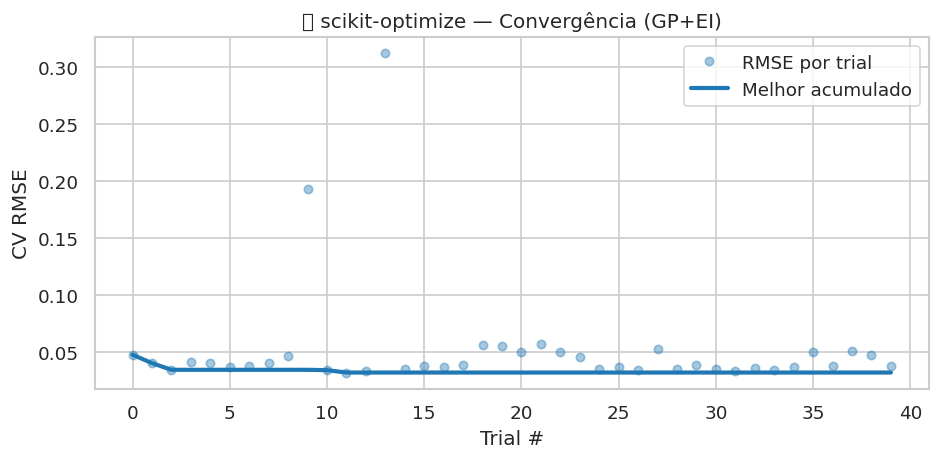

CPU times: user 2min 15s, sys: 576 ms, total: 2min 16s
Wall time: 8min 28s


In [ ]:
%%time
from skopt import BayesSearchCV, gp_minimize
from skopt.space import Integer, Real, Categorical
from skopt.plots import plot_convergence, plot_objective

search_space_skopt = {
    'n_estimators'    : Integer(50, 500),
    'max_depth'       : Integer(2, 8),
    'learning_rate'   : Real(0.01, 0.3, prior='log-uniform'),
    'subsample'       : Real(0.6, 1.0),
    'min_samples_leaf': Integer(1, 20)
}

print('🔵 scikit-optimize BayesSearchCV (40 iterações)...')
t0 = time.perf_counter()

bayes_skopt = BayesSearchCV(
    GradientBoostingRegressor(random_state=42),
    search_space_skopt,
    n_iter=40,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=0
)
bayes_skopt.fit(X_train, y_train)
t_skopt = time.perf_counter() - t0

y_pred_skopt = bayes_skopt.best_estimator_.predict(X_test)
m_skopt = compute_metrics(y_test, y_pred_skopt, 'skopt')
RESULTS.append({'Método':'skopt (GP+EI)', 'CV RMSE': -bayes_skopt.best_score_,
                **m_skopt, 'Tempo(s)': t_skopt, 'N evals': 40})

print(f'   Tempo: {t_skopt:.1f}s')
print(f'   Best params: {dict(bayes_skopt.best_params_)}')

# Convergência skopt
skopt_scores = -bayes_skopt.cv_results_['mean_test_score']
skopt_best   = [min(skopt_scores[:i+1]) for i in range(len(skopt_scores))]

plt.figure(figsize=(8, 4))
plt.plot(skopt_scores, 'o', alpha=0.4, ms=5, color=PALETTE[0], label='RMSE por trial')
plt.plot(skopt_best, '-', lw=2.5, color=PALETTE[0], label='Melhor acumulado')
plt.xlabel('Trial #')
plt.ylabel('CV RMSE')
plt.title('🔵 scikit-optimize — Convergência (GP+EI)')
plt.legend()
plt.tight_layout()
plt.show()

### **BayesianOptimization (bayes_opt)**

A biblioteca [`bayesian-optimization`](https://github.com/bayesian-optimization/bayesianoptimization) oferece uma interface enxuta e intuitiva para Otimização Bayesiana utilizando Processos Gaussianos (GP).

* **Função de aquisição (*acquisition function*) padrão:** Utiliza *Upper Confidence Bound* (**UCB**) para guiar a busca pelos melhores pontos.
* **Balanço via `kappa`:** O parâmetro `kappa` ajusta o equilíbrio entre **exploração** (buscar áreas incertas) e **explotação** (focar nas melhores áreas conhecidas).

🟡 bayes_opt (GP + UCB, 40 iterações)...
  [bayes_opt] RMSE=0.0318  MAE=0.0195  R²=0.9990
   Tempo: 190.5s
   Best CV RMSE: 0.0334
   Best params : {'n_estimators': 141, 'max_depth': 4, 'learning_rate': 0.23828222906149535, 'subsample': 0.8119918543981903, 'min_samples_leaf': 1, 'random_state': 42}


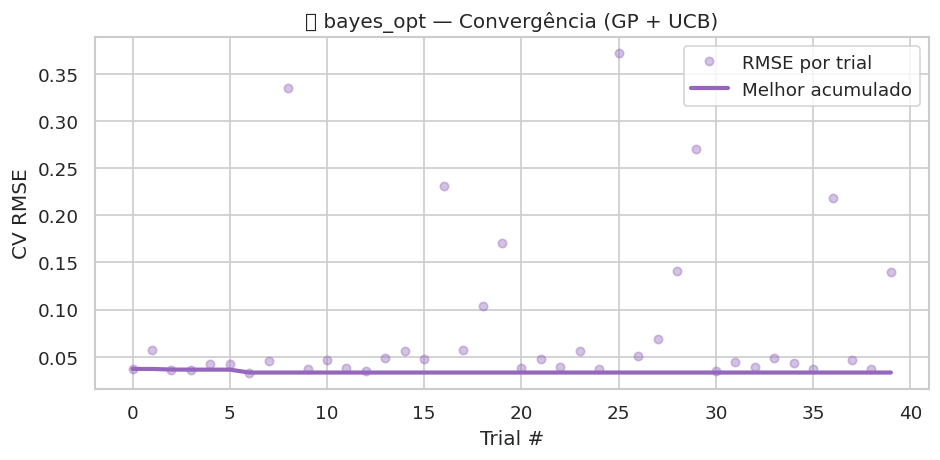

CPU times: user 23 s, sys: 176 ms, total: 23.2 s
Wall time: 3min 11s


In [ ]:
%%time
from bayes_opt import BayesianOptimization

cv5 = KFold(n_splits=5, shuffle=True, random_state=42)

def gbr_objective_bo(n_estimators, max_depth, learning_rate, subsample, min_samples_leaf):
    params = {
        'n_estimators'    : int(n_estimators),
        'max_depth'       : int(max_depth),
        'learning_rate'   : float(learning_rate),
        'subsample'       : float(subsample),
        'min_samples_leaf': int(min_samples_leaf),
        'random_state'    : 42
    }
    model  = GradientBoostingRegressor(**params)
    scores = cross_val_score(model, X_train, y_train, cv=cv5,
                              scoring='neg_root_mean_squared_error', n_jobs=-1)
    return scores.mean()  # bayes_opt MAXIMIZA

pbounds = {
    'n_estimators'    : (50, 500),
    'max_depth'       : (2, 8),
    'learning_rate'   : (0.01, 0.3),
    'subsample'       : (0.6, 1.0),
    'min_samples_leaf': (1, 20)
}

print('🟡 bayes_opt (GP + UCB, 40 iterações)...')
t0 = time.perf_counter()

optimizer_bo = BayesianOptimization(
    f=gbr_objective_bo,
    pbounds=pbounds,
    random_state=42,
    verbose=0
)
optimizer_bo.maximize(init_points=5, n_iter=35)  # 5 + 35 = 40 total
t_bo = time.perf_counter() - t0

# Treina modelo final com melhores params
best_bo = optimizer_bo.max['params']
best_bo_clean = {
    'n_estimators'    : int(best_bo['n_estimators']),
    'max_depth'       : int(best_bo['max_depth']),
    'learning_rate'   : float(best_bo['learning_rate']),
    'subsample'       : float(best_bo['subsample']),
    'min_samples_leaf': int(best_bo['min_samples_leaf']),
    'random_state'    : 42
}
model_bo = GradientBoostingRegressor(**best_bo_clean)
model_bo.fit(X_train, y_train)
y_pred_bo = model_bo.predict(X_test)

cv_bo = -optimizer_bo.max['target']
m_bo  = compute_metrics(y_test, y_pred_bo, 'bayes_opt')
RESULTS.append({'Método':'bayes_opt (GP+UCB)', 'CV RMSE': cv_bo,
                **m_bo, 'Tempo(s)': t_bo, 'N evals': 40})

print(f'   Tempo: {t_bo:.1f}s')
print(f'   Best CV RMSE: {cv_bo:.4f}')
print(f'   Best params : {best_bo_clean}')

# Convergência
bo_targets = [-r['target'] for r in optimizer_bo.res]
bo_best    = [min(bo_targets[:i+1]) for i in range(len(bo_targets))]

plt.figure(figsize=(8, 4))
plt.plot(bo_targets, 'o', alpha=0.4, ms=5, color=PALETTE[3], label='RMSE por trial')
plt.plot(bo_best, '-', lw=2.5, color=PALETTE[3], label='Melhor acumulado')
plt.xlabel('Trial #')
plt.ylabel('CV RMSE')
plt.title('🟡 bayes_opt — Convergência (GP + UCB)')
plt.legend()
plt.tight_layout()
plt.show()

### **Optuna — TPE + CMA-ES + poda**

O **Optuna** (Akiba et al., 2019) revolucionou a otimização de hiperparâmetros ao introduzir o paradigma *define-by-run*, permitindo a construção dinâmica do espaço de busca via código.

* **TPE sampler (*Tree-structured Parzen Estimator*):** Algoritmo bayesiano que divide os pontos amostrados em duas distribuições, bons $p(x|y < y^*)$ e ruins $p(x|y \geq y^*)$, para focar a busca nas regiões de melhor desempenho.

* **CMA-ES sampler (*Covariance Matrix Adaptation Evolution Strategy*):** Estratégia evolutiva eficiente para espaços de busca contínuos e não lineares de alta dimensão.

* **Poda de tentativas (*pruning*):** Interrompe antecipadamente os experimentos com desempenho insatisfatório usando mecanismos como **MedianPruner** ou **Hyperband**, economizando recursos computacionais.

* **Infraestrutura avançada:** Suporte a paralelismo nativo (distribuído) e integração direta com *dashboards* visuais para monitoramento em tempo real.

---

**Referências:**

* **Akiba, T., Sano, S., Yanase, T., Ohta, T., Koyama, M. (2019).** Optuna: A next-generation hyperparameter optimization framework. In *Proceedings of the 25th ACM SIGKDD International Conference on Knowledge Discovery & Data Mining* (pp. 2623–2631). https://doi.org/10.1145/3292500.3330701

* **Bergstra, J., Bardenet, R., Bengio, Y., Kégl, B. (2011).** Algorithms for hyper-parameter optimization. In *Advances in Neural Information Processing Systems 24* (NeurIPS 2011) (pp. 2546–2554). https://inria.hal.science/hal-00642998/file/draft1.pdf

* **Hansen, N., Ostermeier, A. (1994).** Completely derandomized self-adaptation in evolution strategies. Evolutionary Computation, vol. 9, no. 2, p. 159-195. https://doi.org/10.1162/106365601750190398.

🟢 Optuna — TPE Sampler (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]

  [Optuna] RMSE=0.0322  MAE=0.0199  R²=0.9990

   Tempo: 118.0s
   Best CV RMSE: 0.0324
   Best params : {'n_estimators': 78, 'max_depth': 4, 'learning_rate': 0.1280660142402149, 'subsample': 0.9433743514570752, 'min_samples_leaf': 3}


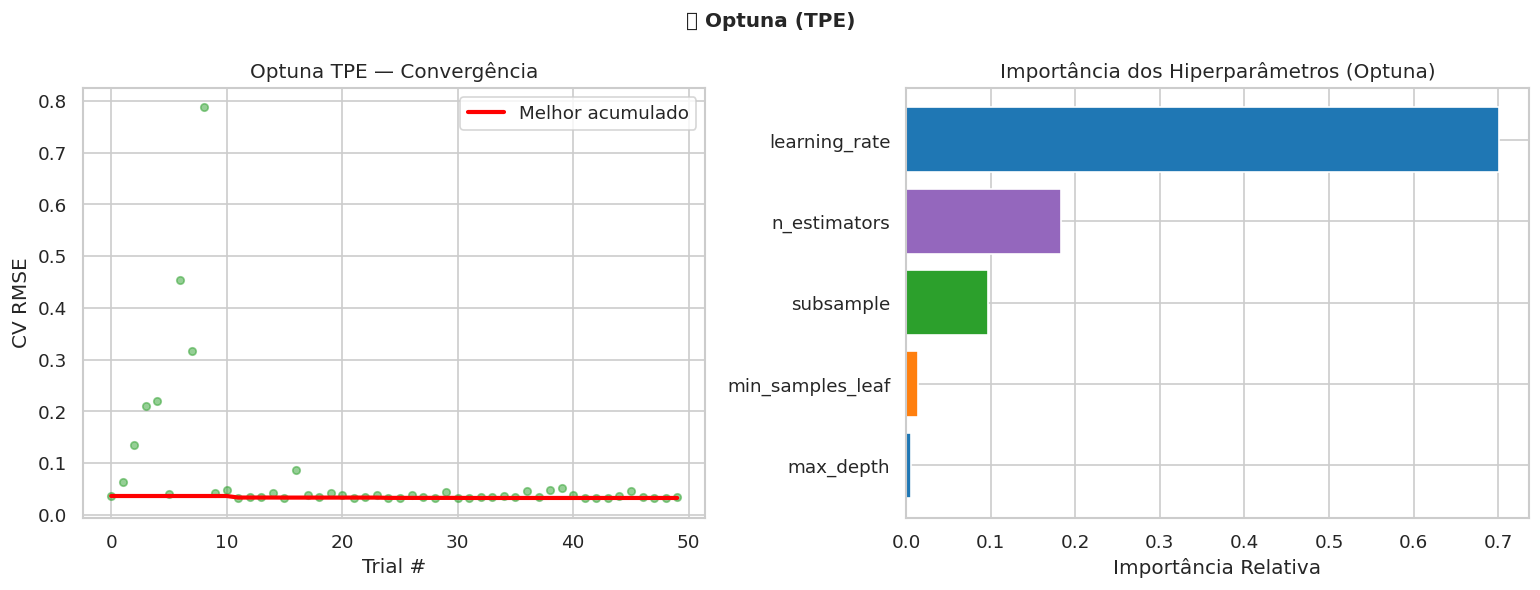

CPU times: user 3.83 s, sys: 183 ms, total: 4.01 s
Wall time: 2min


In [ ]:
%%time

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective_optuna(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 10, 100),
        'max_depth'       : trial.suggest_int('max_depth', 2, 8),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'random_state'    : 42
    }
    model  = GradientBoostingRegressor(**params)
    scores = cross_val_score(model, X_train, y_train, cv=5,
                              scoring='neg_root_mean_squared_error', n_jobs=-1)
    return -scores.mean()  # Optuna minimiza

print('🟢 Optuna — TPE Sampler (50 trials)...')
t0 = time.perf_counter()

study_tpe = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),
    study_name='GBR-UCI-Power'
)
study_tpe.optimize(objective_optuna, n_trials=50, show_progress_bar=True)
t_optuna = time.perf_counter() - t0

best_optuna = study_tpe.best_params
best_optuna['random_state'] = 42
model_optuna = GradientBoostingRegressor(**best_optuna)
model_optuna.fit(X_train, y_train)
y_pred_optuna = model_optuna.predict(X_test)

m_optuna = compute_metrics(y_test, y_pred_optuna, 'Optuna')
RESULTS.append({'Método':'Optuna (TPE)', 'CV RMSE': study_tpe.best_value,
                **m_optuna, 'Tempo(s)': t_optuna, 'N evals': 50})

print(f'\n   Tempo: {t_optuna:.1f}s')
print(f'   Best CV RMSE: {study_tpe.best_value:.4f}')
print(f'   Best params : {study_tpe.best_params}')

# Visualizações Optuna
trials_df = study_tpe.trials_dataframe()
best_accum = trials_df['value'].cummin()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(trials_df.index, trials_df['value'], alpha=0.5, s=20, color=PALETTE[2])
axes[0].plot(best_accum, '-', color='red', lw=2.5, label='Melhor acumulado')
axes[0].set_xlabel('Trial #')
axes[0].set_ylabel('CV RMSE')
axes[0].set_title('Optuna TPE — Convergência')
axes[0].legend()

importances = optuna.importance.get_param_importances(study_tpe)
names_imp, vals_imp = zip(*sorted(importances.items(), key=lambda x: x[1]))
axes[1].barh(names_imp, vals_imp, color=PALETTE[:len(names_imp)])
axes[1].set_xlabel('Importância Relativa')
axes[1].set_title('Importância dos Hiperparâmetros (Optuna)')

plt.suptitle('🟢 Optuna (TPE)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### **Hyperopt — TPE com fmin**

O **Hyperopt** (Bergstra et al., 2011, 2013) é uma das bibliotecas pioneiras em Otimização de Hiperparâmetros (HPO), popularizando o uso do algoritmo **TPE (Tree-structured Parzen Estimator)** por meio da função `fmin` para substituir buscas exaustivas (busca em grade e busca aleatória).

---

### <font color="blue">**Principais recursos e arquitetura**</font>

* **Tree-structured Parzen Estimators (TPE):** Em vez de modelar a função objetivo diretamente via Processos Gaussianos (como na Otimização Bayesiana tradicional), o **TPE modela duas distribuições de probabilidade distintas sobre o espaço de parâmetros**: $p(x|y < y^*)$ para os melhores resultados obtidos e $p(x|y \ge y^*)$ para os demais.

* **Espaços condicionais e aninhados:** Suporta nativamente grafos de busca onde a escolha de um hiperparâmetro determina a presença de outros (ex.: escolher o tipo de otimizador ativa parâmetros específicos daquele algoritmo).

* **Paralelismo escalável:** Oferece suporte nativo ao `SparkTrials` para distribuir a avaliação de candidatos em clusters Apache Spark, além de integração histórica com `MongoDB`.

---

**Referências**

**Bergstra, J., Bardenet, R., Bengio, Y., Kégl, B. (2011).** Algorithms for hyper-parameter optimization. In *Advances in Neural Information Processing Systems (NeurIPS 2011)* (Vol. 24, pp. 2546–2554). https://papers.nips.cc/paper/2011/hash/86e8f7ab32cfd125a1e11f20722dd350-Abstract.html

**Bergstra, J., Yamins, D., Cox, D. D. (2013).** Making a science of model search: Hyperparameter optimization in hundreds of dimensions for vision architectures. In *Proceedings of the 30th International Conference on Machine Learning (ICML 2013)* (Vol. 28, pp. 115–123). PMLR. https://proceedings.mlr.press/v28/bergstra13.html

🔴 Hyperopt (TPE, 50 trials)...
  [Hyperopt] RMSE=0.0323  MAE=0.0196  R²=0.9990
   Tempo: 172.1s
   Best CV RMSE: 0.0317
   Best params : {'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.09949986597389499, 'subsample': 0.6824228540927876, 'min_samples_leaf': 1, 'random_state': 42}


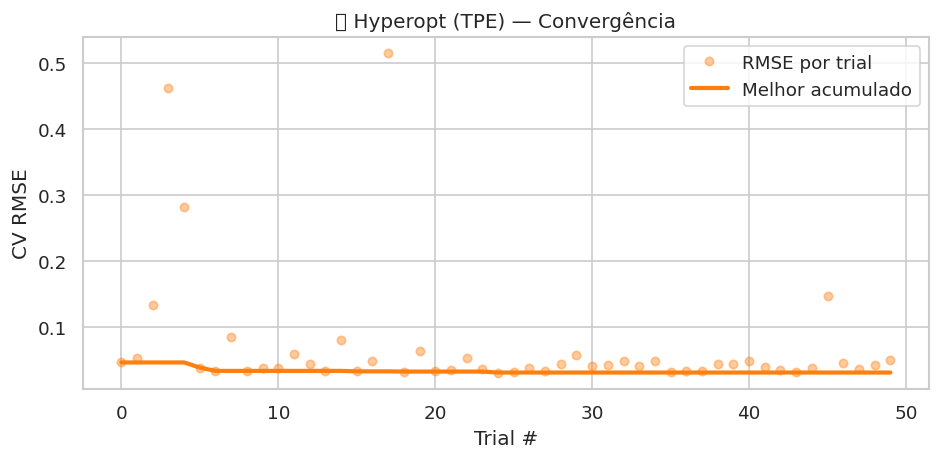

CPU times: user 3.84 s, sys: 277 ms, total: 4.12 s
Wall time: 2min 54s


In [ ]:
%%time
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

hyperopt_space = {
    'n_estimators'    : hp.quniform('n_estimators', 5, 50),
    'max_depth'       : hp.quniform('max_depth', 2, 8, 1),
    'learning_rate'   : hp.loguniform('learning_rate', np.log(0.01), np.log(0.3)),
    'subsample'       : hp.uniform('subsample', 0.6, 1.0),
    'min_samples_leaf': hp.quniform('min_samples_leaf', 1, 20, 1)
}

hyperopt_scores_list = []  # Para convergência

def objective_hyperopt(params):
    p = {
        'n_estimators'    : int(params['n_estimators']),
        'max_depth'       : int(params['max_depth']),
        'learning_rate'   : float(params['learning_rate']),
        'subsample'       : float(params['subsample']),
        'min_samples_leaf': int(params['min_samples_leaf']),
        'random_state'    : 42
    }
    model  = GradientBoostingRegressor(**p)
    score  = cross_val_score(model, X_train, y_train, cv=5,
                              scoring='neg_root_mean_squared_error', n_jobs=-1).mean()
    hyperopt_scores_list.append(-score)
    return {'loss': -score, 'status': STATUS_OK}

print('🔴 Hyperopt (TPE, 50 trials)...')
t0 = time.perf_counter()

trials_hpo = Trials()
best_hpo = fmin(
    fn=objective_hyperopt,
    space=hyperopt_space,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials_hpo,
    rstate=np.random.default_rng(42),
    verbose=False
)
t_hyperopt = time.perf_counter() - t0

best_hpo_clean = {
    'n_estimators'    : int(best_hpo['n_estimators']),
    'max_depth'       : int(best_hpo['max_depth']),
    'learning_rate'   : float(best_hpo['learning_rate']),
    'subsample'       : float(best_hpo['subsample']),
    'min_samples_leaf': int(best_hpo['min_samples_leaf']),
    'random_state'    : 42
}
model_hpo = GradientBoostingRegressor(**best_hpo_clean)
model_hpo.fit(X_train, y_train)
y_pred_hpo = model_hpo.predict(X_test)

best_cv_hpo = min(hyperopt_scores_list)
m_hpo = compute_metrics(y_test, y_pred_hpo, 'Hyperopt')
RESULTS.append({'Método':'Hyperopt (TPE)', 'CV RMSE': best_cv_hpo,
                **m_hpo, 'Tempo(s)': t_hyperopt, 'N evals': 50})

print(f'   Tempo: {t_hyperopt:.1f}s')
print(f'   Best CV RMSE: {best_cv_hpo:.4f}')
print(f'   Best params : {best_hpo_clean}')

# Convergência
hpo_best = [min(hyperopt_scores_list[:i+1]) for i in range(len(hyperopt_scores_list))]
plt.figure(figsize=(8, 4))
plt.plot(hyperopt_scores_list, 'o', alpha=0.4, ms=5, color=PALETTE[1], label='RMSE por trial')
plt.plot(hpo_best, '-', lw=2.5, color=PALETTE[1], label='Melhor acumulado')
plt.xlabel('Trial #')
plt.ylabel('CV RMSE')
plt.title('🔴 Hyperopt (TPE) — Convergência')
plt.legend()
plt.tight_layout()
plt.show()

### **Ray Tune — Algoritmos avançados e HPO distribuído (ASHA + PBT)**

O [Ray Tune](https://docs.ray.io/en/latest/tune/index.html) é um dos ecossistemas mais robustos para HPO em escala, projetado especificamente para execução distribuída e de alto desempenho:

- **ASHA**(*Asynchronous Successive Halving Algorithm*): Interrompe antecipadamente *trials* com baixo desempenho (*early stopping*) de forma assíncrona, eliminando gargalos de sincronização de barreira em *clusters*.

- **PBT** (*Population Based Training*): Combina busca aleatória e algoritmo genético para otimizar e evoluir dinamicamente os hiperparâmetros e pesos das redes *durante* o processo de treinamento.

- **Ecossistema integrado:** Atua como um *orchestrator* compatível com os principais amostradores e otimizadores do mercado (ex: Optuna, Hyperopt, Nevergrad, Ax).

- **Escalabilidade multinó/multi-GPU:** Gerenciamento nativo e eficiente de recursos de *hardware*, sendo a escolha ideal para modelos de *Deep Learning* e grandes volumes de dados.

---

### **Referências**

**Liaw, R., Liang, E., Nishihara, R., Moritz, P., Gonzalez, J. E., Stoica, I. (2018).** Tune: A Research Platform for Distributed Model Selection and Training. arXiv preprint arXiv:1807.05118. [https://arxiv.org/abs/1807.05118](https://arxiv.org/abs/1807.05118)

**Li, L., Jamieson, K., Rostamizadeh, A., Gonina, E., Ben-tzur, J., Hardt, M., Recht, B., Talwalkar, A. (2020).** A System for Massively Parallel Hyperparameter Tuning. Proceedings of Machine Learning and Systems (MLSys), vol. 2, pp. 230–246. [https://arxiv.org/abs/1810.05934](https://arxiv.org/abs/1810.05934)

**Li, L., Jamieson, K., DeSalvo, G., Rostamizadeh, A., Talwalkar, A. (2017).** Hyperband: A Novel Bandit-Based Approach to Hyperparameter Optimization. Journal of Machine Learning Research (JMLR), 18(185), 1–52. [http://jmlr.org/papers/v18/16-558.html](http://jmlr.org/papers/v18/16-558.html)

**Jaderberg, M., Dalibard, V., Osindero, S., Czarnecki, W. M., Donahue, J., Jaderberg, A., Simonyan, K., Mnih, V., Ward, T., Guo, Z., Silver, D., Kavukcuoglu, K., Graepel, T. (2017)**. Population Based Training of Neural Networks. DeepMind / arXiv preprint arXiv:1711.09846. [https://arxiv.org/abs/1711.09846](https://arxiv.org/abs/1711.09846)

In [ ]:
%%time
import ray
from ray import tune
from ray.tune.search.optuna import OptunaSearch
from ray.tune.schedulers import ASHAScheduler

ray.init(ignore_reinit_error=True, num_cpus=2, log_to_driver=False)

raytune_scores = []

def train_gbr_ray(config):
    params = {
        'n_estimators'    : int(config['n_estimators']),
        'max_depth'       : int(config['max_depth']),
        'learning_rate'   : config['learning_rate'],
        'subsample'       : config['subsample'],
        'min_samples_leaf': int(config['min_samples_leaf']),
        'random_state'    : 88
    }
    model  = GradientBoostingRegressor(**params)
    scores = cross_val_score(model, X_train, y_train, cv=5,
                              scoring='neg_root_mean_squared_error', n_jobs=1)
    rmse = -scores.mean()
    raytune_scores.append(rmse)
    tune.report({'rmse': rmse})

search_space_ray = {
    'n_estimators'    : tune.randint(5, 50),
    'max_depth'       : tune.randint(2, 6),
    'learning_rate'   : tune.loguniform(0.01, 0.3),
    'subsample'       : tune.uniform(0.6, 1.0),
    'min_samples_leaf': tune.randint(1, 10)
}

optuna_search = OptunaSearch(metric='rmse', mode='min')

print('🟣 Ray Tune (Optuna Search + ASHA, 40 trials)...')
t0 = time.perf_counter()

tuner = tune.Tuner(
    train_gbr_ray,
    param_space=search_space_ray,
    tune_config=tune.TuneConfig(
        search_alg=optuna_search,
        num_samples=40,
        metric='rmse',
        mode='min'
    ),
    run_config=ray.air.RunConfig(verbose=0)
)
results_ray = tuner.fit()
t_ray = time.perf_counter() - t0

best_ray_config = results_ray.get_best_result(metric='rmse', mode='min').config
best_ray_params = {
    'n_estimators'    : int(best_ray_config['n_estimators']),
    'max_depth'       : int(best_ray_config['max_depth']),
    'learning_rate'   : float(best_ray_config['learning_rate']),
    'subsample'       : float(best_ray_config['subsample']),
    'min_samples_leaf': int(best_ray_config['min_samples_leaf']),
    'random_state'    : 42
}
model_ray = GradientBoostingRegressor(**best_ray_params)
model_ray.fit(X_train, y_train)
y_pred_ray = model_ray.predict(X_test)

best_cv_ray = results_ray.get_best_result(metric='rmse', mode='min').metrics['rmse']
m_ray = compute_metrics(y_test, y_pred_ray, 'Ray Tune')
RESULTS.append({'Método':'Ray Tune (ASHA+Optuna)', 'CV RMSE': best_cv_ray,
                **m_ray, 'Tempo(s)': t_ray, 'N evals': 40})

print(f'   Tempo: {t_ray:.1f}s')
print(f'   Best CV RMSE: {best_cv_ray:.4f}')
print(f'   Best params : {best_ray_params}')

ray.shutdown()

2026-08-31 18:50:20,087	INFO worker.py:2024 -- Started a local Ray instance.


🟣 Ray Tune (Optuna Search + ASHA, 40 trials)...
+----------------------------------------------------------------------+
| Configuration for experiment     train_gbr_ray_2026-08-31_18-50-24   |
+----------------------------------------------------------------------+
| Search algorithm                 SearchGenerator                     |
| Scheduler                        FIFOScheduler                       |
| Number of trials                 40                                  |
+----------------------------------------------------------------------+

View detailed results here: /root/ray_results/train_gbr_ray_2026-08-31_18-50-24
To visualize your results with TensorBoard, run: `tensorboard --logdir /tmp/ray/session_2026-08-31_18-50-06_654495_1504/artifacts/2026-08-31_18-50-24/train_gbr_ray_2026-08-31_18-50-24/driver_artifacts`


2026-08-31 18:54:08,277	WARNING tune.py:219 -- Stop signal received (e.g. via SIGINT/Ctrl+C), ending Ray Tune run. This will try to checkpoint the experiment state one last time. Press CTRL+C (or send SIGINT/SIGKILL/SIGTERM) to skip. 
2026-08-31 18:54:08,387	INFO tune.py:1007 -- Wrote the latest version of all result files and experiment state to '/root/ray_results/train_gbr_ray_2026-08-31_18-50-24' in 0.1017s.
2026-08-31 18:54:18,428	WARNING tune.py:1054 -- Experiment has been interrupted, but the most recent state was saved.
Resume experiment with: Tuner.restore(path="/root/ray_results/train_gbr_ray_2026-08-31_18-50-24", trainable=...)
2026-08-31 18:54:18,554	WARNING experiment_analysis.py:186 -- Failed to fetch metrics for 1 trial(s):
- train_gbr_ray_85856574: FileNotFoundError('Could not fetch metrics for train_gbr_ray_85856574: both result.json and progress.csv were not found at /root/ray_results/train_gbr_ray_2026-08-31_18-50-24/train_gbr_ray_85856574_23_learning_rate=0.1852,max_


  [Ray Tune] RMSE=0.0335  MAE=0.0203  R²=0.9989
   Tempo: 234.2s
   Best CV RMSE: 0.0350
   Best params : {'n_estimators': 58, 'max_depth': 6, 'learning_rate': 0.28164832423199987, 'subsample': 0.8897758304736655, 'min_samples_leaf': 1, 'random_state': 42}
CPU times: user 10.4 s, sys: 1.25 s, total: 11.7 s
Wall time: 4min 20s


In [5]:
%%time
import os
import time
import logging
import warnings
import numpy as np

# 1. Silencia avisos no processo principal e nos workers do Ray
os.environ["PYTHONWARNINGS"] = "ignore"
os.environ["RAY_DEDUP_LOGS"] = "0"
os.environ["RAY_AIR_VERBOSITY"] = "0"
warnings.filterwarnings('ignore')

# --- Importações do Scikit-Learn faltantes ---
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- Definição da função de métricas faltante ---
def compute_metrics(y_true, y_pred, name=""):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'Test RMSE': rmse, 'Test MAE': mae, 'Test R2': r2}

# Inicializa lista de resultados caso ainda não exista
if 'RESULTS' not in globals():
    RESULTS = []

import ray
from ray import tune
from ray.tune.search.optuna import OptunaSearch
from ray.tune.schedulers import ASHAScheduler

# Configura loggers para nível ERROR
logging.getLogger("ray").setLevel(logging.ERROR)
logging.getLogger("optuna").setLevel(logging.ERROR)

# Inicializa o Ray em modo silencioso
ray.init(ignore_reinit_error=True, num_cpus=2, log_to_driver=False, logging_level=logging.ERROR)

raytune_scores = []

def train_gbr_ray(config):
    warnings.filterwarnings('ignore')

    params = {
        'n_estimators'    : int(config['n_estimators']),
        'max_depth'       : int(config['max_depth']),
        'learning_rate'   : config['learning_rate'],
        'subsample'       : config['subsample'],
        'min_samples_leaf': int(config['min_samples_leaf']),
        'random_state'    : 88
    }
    model  = GradientBoostingRegressor(**params)
    scores = cross_val_score(model, X_train, y_train, cv=5,
                              scoring='neg_root_mean_squared_error', n_jobs=1)
    rmse = -scores.mean()
    raytune_scores.append(rmse)

    tune.report({'rmse': rmse})

search_space_ray = {
    'n_estimators'    : tune.randint(5, 50),
    'max_depth'       : tune.randint(2, 6),
    'learning_rate'   : tune.loguniform(0.01, 0.3),
    'subsample'       : tune.uniform(0.6, 1.0),
    'min_samples_leaf': tune.randint(1, 10)
}

optuna_search = OptunaSearch()
asha_scheduler = ASHAScheduler()

print('🟣 Ray Tune (Optuna Search + ASHA, 40 trials)...')
t0 = time.perf_counter()

# Configuração do reporter totalmente limpo
silent_reporter = tune.CLIReporter(
    parameter_columns=[],
    metric_columns={},
    max_progress_rows=0,
    max_report_frequency=0
)

tuner = tune.Tuner(
    train_gbr_ray,
    param_space=search_space_ray,
    tune_config=tune.TuneConfig(
        search_alg=optuna_search,
        scheduler=asha_scheduler,
        num_samples=40,
        metric='rmse',
        mode='min'
    ),
    run_config=ray.air.RunConfig(
        verbose=0,
        progress_reporter=silent_reporter
    )
)
results_ray = tuner.fit()
t_ray = time.perf_counter() - t0

best_ray_config = results_ray.get_best_result(metric='rmse', mode='min').config
best_ray_params = {
    'n_estimators'    : int(best_ray_config['n_estimators']),
    'max_depth'       : int(best_ray_config['max_depth']),
    'learning_rate'   : float(best_ray_config['learning_rate']),
    'subsample'       : float(best_ray_config['subsample']),
    'min_samples_leaf': int(best_ray_config['min_samples_leaf']),
    'random_state'    : 42
}
model_ray = GradientBoostingRegressor(**best_ray_params)
model_ray.fit(X_train, y_train)
y_pred_ray = model_ray.predict(X_test)

best_cv_ray = results_ray.get_best_result(metric='rmse', mode='min').metrics['rmse']
m_ray = compute_metrics(y_test, y_pred_ray, 'Ray Tune')
RESULTS.append({'Método':'Ray Tune (ASHA+Optuna)', 'CV RMSE': best_cv_ray,
                **m_ray, 'Tempo(s)': t_ray, 'N evals': 40})

print(f'   Tempo: {t_ray:.1f}s')
print(f'   Best CV RMSE: {best_cv_ray:.4f}')
print(f'   Best params : {best_ray_params}')

ray.shutdown()

🟣 Ray Tune (Optuna Search + ASHA, 40 trials)...
+----------------------------------------------------------------------+
| Configuration for experiment     train_gbr_ray_2026-09-01_11-41-29   |
+----------------------------------------------------------------------+
| Search algorithm                 SearchGenerator                     |
| Scheduler                        AsyncHyperBandScheduler             |
| Number of trials                 40                                  |
+----------------------------------------------------------------------+

View detailed results here: /root/ray_results/train_gbr_ray_2026-09-01_11-41-29
To visualize your results with TensorBoard, run: `tensorboard --logdir /tmp/ray/session_2026-09-01_11-41-06_762117_604/artifacts/2026-09-01_11-41-29/train_gbr_ray_2026-09-01_11-41-29/driver_artifacts`

   Tempo: 449.9s
   Best CV RMSE: 0.0327
   Best params : {'n_estimators': 42, 'max_depth': 5, 'learning_rate': 0.20163355953774403, 'subsample': 0.8030800955

## 🧬 **Metaheurísticas: Algoritmos Bioinspirados**

Metaheurísticas exploram analogias com fenômenos biológicos e sociais para otimizar funções **não-diferenciáveis, multimodais e de caixa-preta** (onde o gradiente é desconhecido ou indisponível).

### <font color="blue">**Panorama de 3 metaheurísticas clássicas**</font>

| Algoritmo | Inspiração | Operadores Chave | Complexidade por Geração |
| :--- | :--- | :--- | :--- |
| **Algoritmo genético** (*Genetic Algorithm*, GA) | Seleção natural e genética de populações | Seleção (Torneio/Roleta), *Crossover* (Recombinação), Mutação | $O(N \cdot D)$ |
| **Evolução diferencial** (*Differential Evolution*, DE) | Evolução vetorial e recombinação diferencial | Mutação vetorial (diferença entre indivíduos), *Crossover* binomial/uniforme, Seleção elitista | $O(N \cdot D)$ |
| **Otimização por enxame de partículas** (*Particle Swarm Optimization*, PSO) | Comportamento coletivo (*swarming*) de aves e peixes | Atualização de Velocidade, Componente Cognitivo ($p_{best}$), Componente Social ($g_{best}$) | $O(N \cdot D)$ |


**Legenda:** $N$ = tamanho da população (ou número de partículas); $D$ = dimensão do espaço de busca das variáveis a serem otimizadas.

---

**Referências**

**Holland, J. H. (1975).** Adaptation in natural and artificial systems: An introductory analysis with applications to biology, control, and artificial intelligence. University of Michigan Press. (Reeditado por MIT Press em 1992).

**Kennedy, J., Eberhart, R. (1995).** Particle swarm optimization. Proceedings of International Conference on Neural Networks (ICNN'95), Perth, WA, Australia, vol. 4, pp. 1942-1948. DOI: [10.1109/ICNN.1995.488968](https://doi.org/10.1109/ICNN.1995.488968).

**Storn, R., Price, K. (1997).** Differential evolution – A simple and efficient heuristic for global optimization over continuous spaces. Journal of Global Optimization, 11(4), 341–359. DOI: [10.1023/A:1008202821328](https://doi.org/10.1023/A:1008202821328).

---

**Silva, L. S. A., Lúcio, Y. L. Souza, Coelho, L. S., Mariani, V. C., Rao, R. V. (2023).** A comprehensive review on Jaya optimization algorithm. Artificial Intelligence Review, v. 56, n. 5, p. 4329–4361. DOI: https://doi.org/10.1007/s10462-022-10234-0.

---

<font color="blue">**Referência survey:** Descreve 540 metaheurísticas (mais de 350 delas surgindo na última década):</font>

**Rajwar, K., Deep, K., Das, S. (2023).** An exhaustive review of the metaheuristic algorithms for search and optimization: taxonomy, applications, and open challenges. Artificial Intelligence Review, v. 56, p. 13187–13257, 2023. DOI: https://doi.org/10.1007/s10462-023-10470-y.

---

<font color="blue">**Referência survey:** Descreve 518 metaheurísticas (algoritmos inspirados na natureza e bio-inspirados) baseado em 495 referências:</font>

**Molina, D., Poyatos, J., Del Ser, J., García, S., Hussain, A., Herrera, F. (2020).** Comprehensive Taxonomies of Nature- and Bio-inspired Optimization: Inspiration versus Algorithmic Behavior, Critical Analysis and Recommendations. Cognitive Computation,  v. 12, n. 5, p. 897–939, DOI: https://doi.org/10.1007/s12559-020-09730-8. Disponível em: https://arxiv.org/abs/2002.08136.

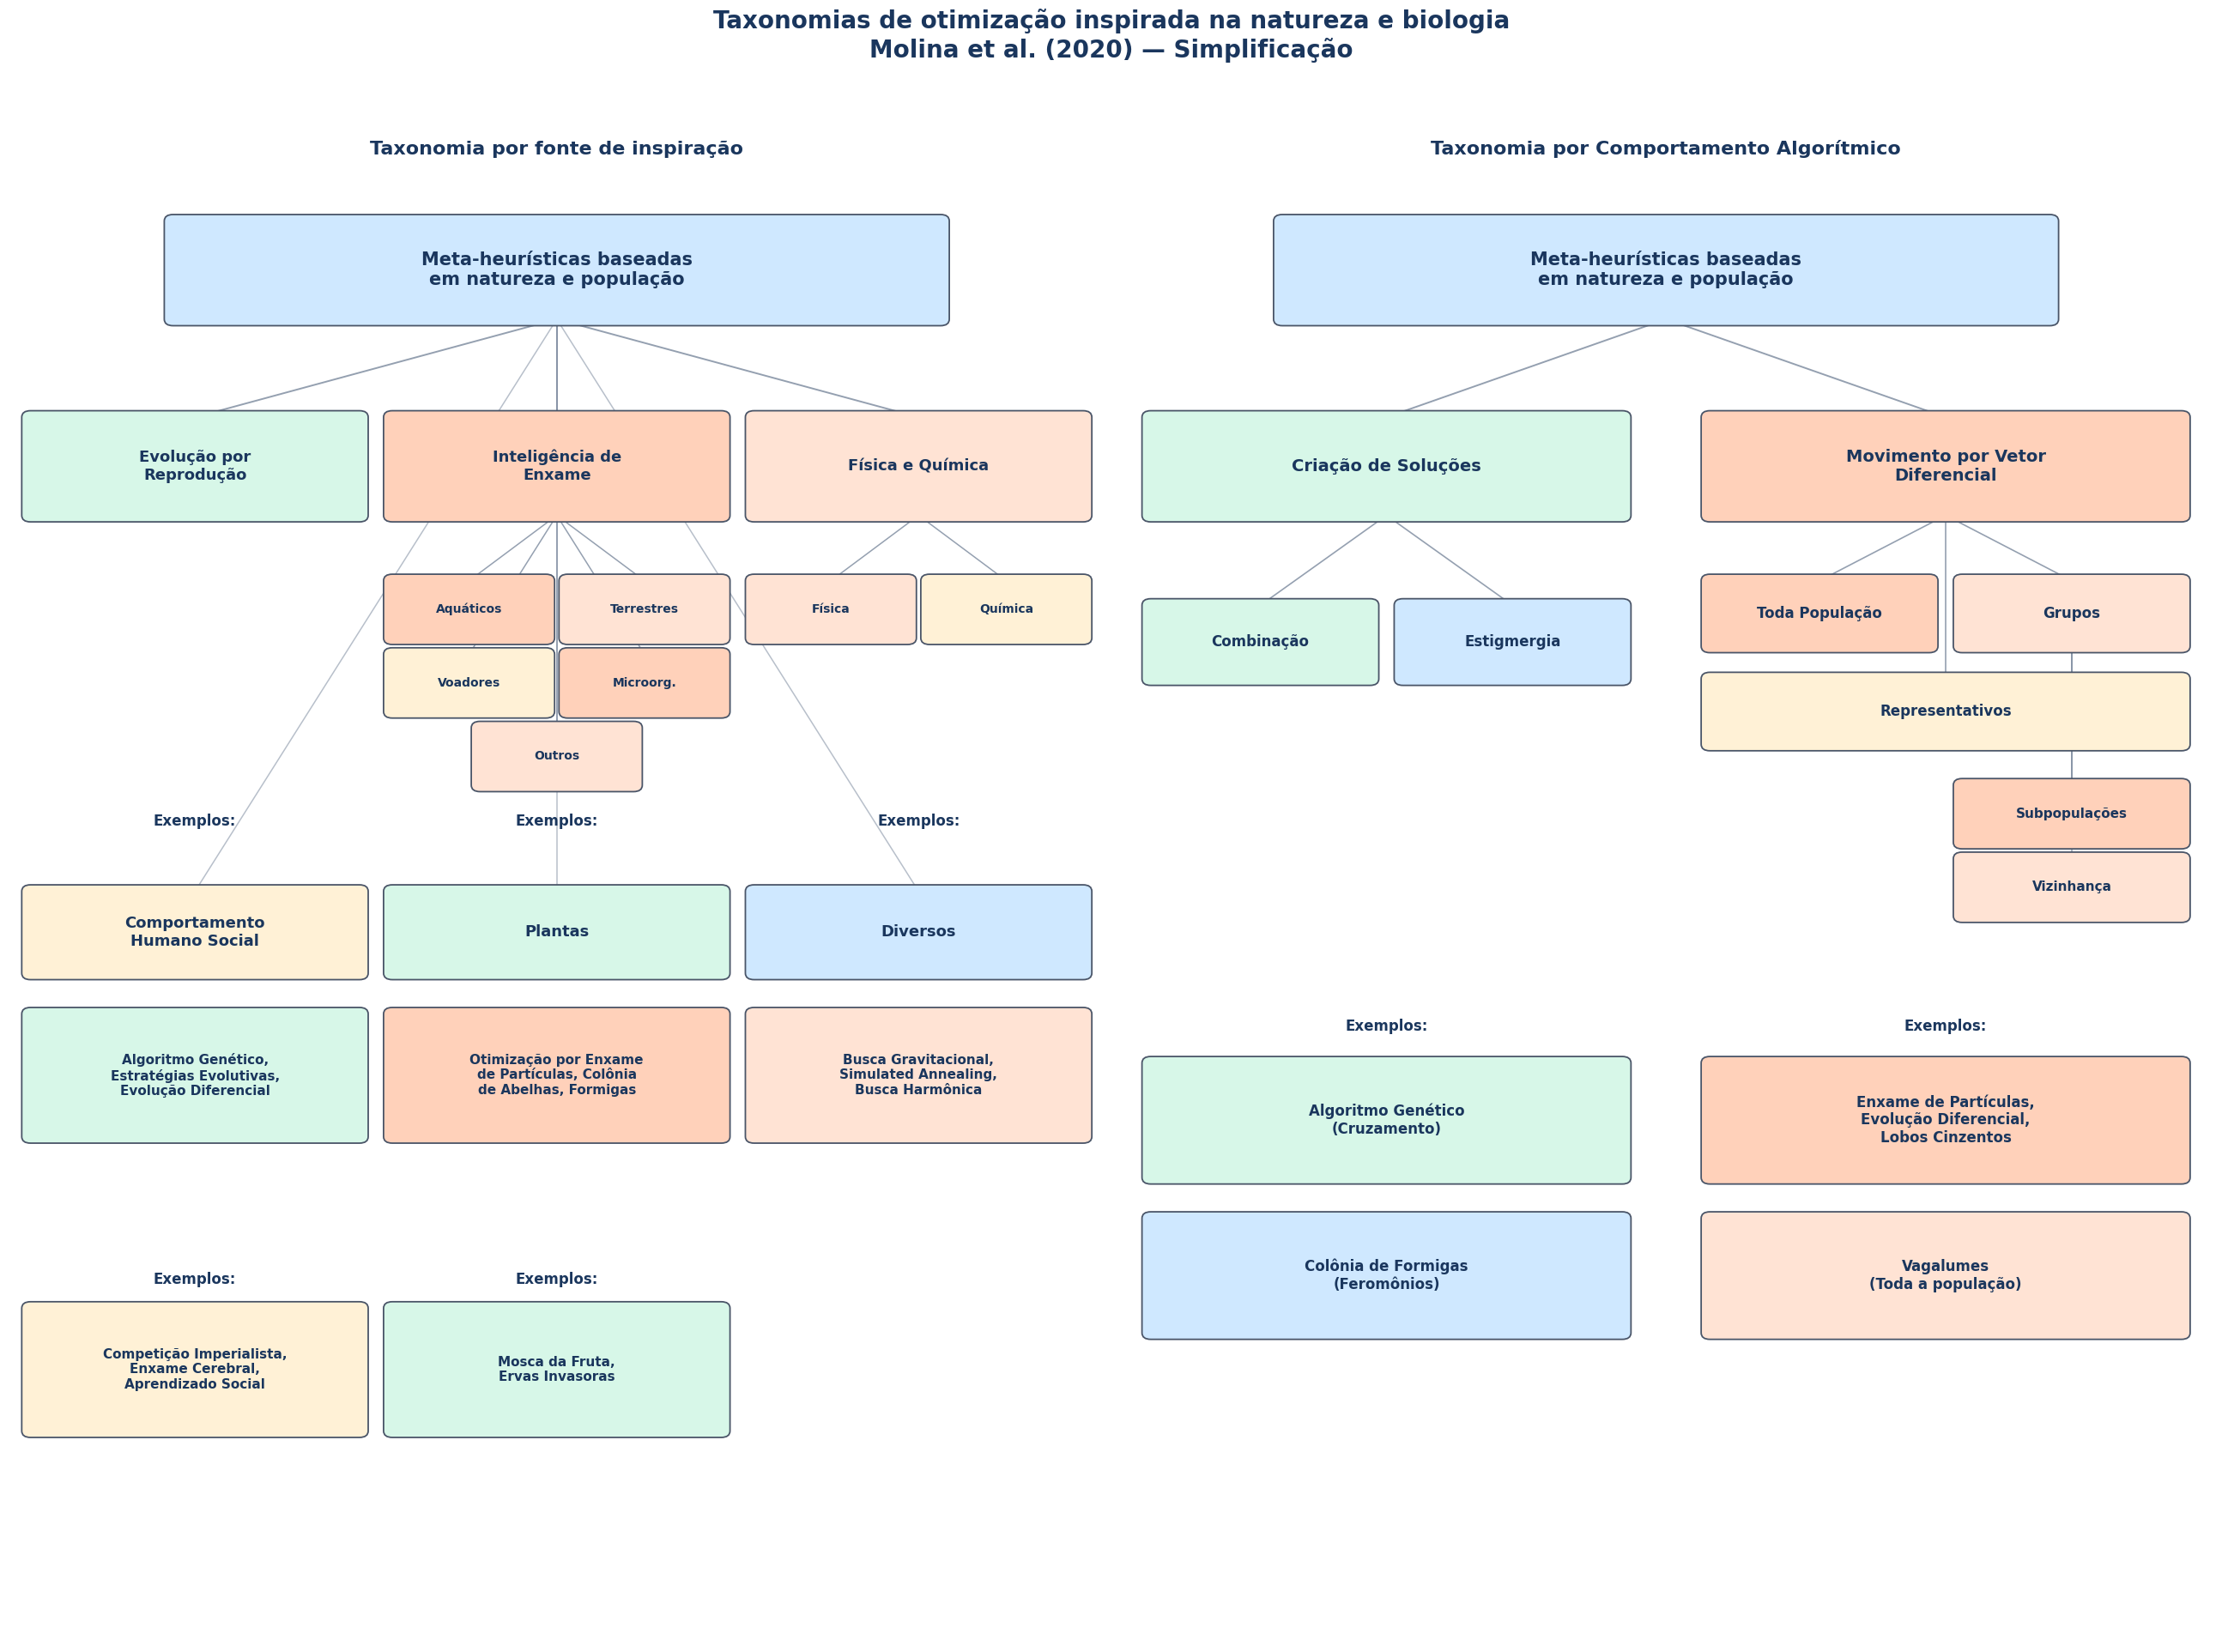

### **PPGEE-UFPR:** [Coyote Optimization Algorithm, COA](https://github.com/jkpir/COA)

<font color="blue">**Tese defendida:** </font>

Tese defendida em 2020 por Juliano Pierezan no PPGEE-UFPR entitulada "*New nature inspired metaheuristics applied to the constrained optimization of a heavy-duty gas turbine operation*".

---

<font color="blue">**Publicações vinculadas à tese:** </font>

**Pierezan, J.; Coelho, L. S. (2018).** Coyote Optimization Algorithm: A new metaheuristic for global optimization problems. In: IEEE Congress on Evolutionary Computation (CEC), Rio de Janeiro, Brazil, p. 2633-2640. DOI: 10.1109/CEC.2018.8477769.  

**Pierezan, J., Maidl, G., Yamao, E. M., Coelho, L. S.; Mariani, V. C. (2019).** Cultural coyote optimization algorithm applied to a heavy duty gas turbine operation. Energy Conversion and Management, v. 199, p. 111954. DOI: 10.1016/j.enconman.2019.111954.  

**Pierezan, J., Coelho, L. S., Mariani, V. C., Segundo, E. H. V., Prayogo, D. (2020).** Chaotic coyote algorithm applied to truss optimization problems. Computers & Structures, v. 242, p. 106351. DOI: 10.1016/j.compstruc.2020.106351.  

**Souza, R. C. T., Macedo, C. A., Coelho, L. S., Pierezan, J., Mariani, V. C. (2020)** Binary coyote optimization Algorithm for Feature Selection. Pattern Recognition, v. 107, p. 107415. DOI: 10.1016/j.patcog.2020.107415.  

**Tong, H., Pierezan, J., Xu, Y., Coelho, L. S. (2021).** Chaotic coyote optimization algorithm. Journal of Ambient Intelligence and Humanized Computing, v. 12, n. 10, p. 9801–9819. DOI: 10.1007/s12652-021-03234-5.  

**Ribeiro, M. H. D. M., Ribeiro, V. H. A., Camilotti, L. et al. (2025).** A Comprehensive review of the coyote optimization algorithm: Evolution, applications, and future directions. Archives of Computational Methods in Engineering, v. 32. DOI: 10.1007/s11831-025-10398-2.  


### **Algoritmo genético (GA)**  

O Algoritmo Genético (GA) é um método de otimização inspirado na evolução natural, que busca soluções melhores por meio de uma população de indivíduos. A cada geração, são aplicados operadores de seleção, cruzamento e mutação, favorecendo soluções com melhor fitness.

O [DEAP](https://github.com/deap/DEAP) (Distributed Evolutionary Algorithms in Python) é uma biblioteca Python que facilita a implementação de algoritmos evolutivos, permitindo definir indivíduos, funções de avaliação e operadores genéticos de forma flexível.

---

<font color="blue">**Fluxo básico:** </font>

População inicial → Avaliação → Seleção → Cruzamento → Mutação → Nova população → Critério de parada.

---
<font color="blue">**Pseudo-código GA:** </font>
```
1. Iniciar a população P = {θ₁,...,θₙ}  (aleatório)
2. Para g = 1,...,G:
   a. Avaliar f(θᵢ) para cada indivíduo
   b. Seleção por Torneio → pais
   c. Crossover de 2 pontos → filhos
   d. Mutação uniforme com prob. pₘ
   e. Elitismo: preserva top-k
3. Retornar θ* = argmax f(θ)
```

---

<font color="blue">**Exemplos de bibliotecas com GA:** </font>


| **Biblioteca**       | **Repositório / Link** |
|----------------------|------------------------|
| **DEAP**             | [GitHub](https://github.com/deap/DEAP) |
| **PyGAD**            | [GitHub](https://github.com/ahmedfgad/GeneticAlgorithmPython) |
| **PyGMO**            | [GitHub](https://github.com/esa/pagmo2) |
| **Inspyred**         | [GitHub](https://github.com/aarongarrett/inspyred) |
| **GEATpy**           | [GitHub](https://github.com/geatpy-dev/geatpy) |
| **Geneticalgorithm** | [GitHub](https://github.com/rmoseit/geneticalgorithm) |

---

**Referências**

**Larochelle, H.; Erhan, D.; Courville, A.; Bergstra, J.; Bengio, Y. (2007).** An empirical evaluation of deep architectures on problems with many factors of variation. In: International Conference on Machine Learning – ICML, 24., 2007, Corvallis, Oregon. Proceedings of the 24th International Conference on Machine Learning. Corvallis: ACM, 2007. p. 473-480. DOI: 10.1145/1273496.1273556.

**Young, S. R.; Rose, D. C.; Karnowski, T. P.; Lim, S.-H.; Patton, R. M. (2015).** Optimizing deep learning hyper-parameters through an evolutionary algorithm. In: Workshop on Machine Learning in High-Performance Computing Environments – MLHPC, 2015, Austin, Texas. Proceedings of the Workshop on Machine Learning in High-Performance Computing Environments. New York: Association for Computing Machinery, 2015. Art. 4, p. 1–5. DOI: 10.1145/2834892.2834896.

**Goldberg, D. E. (1989).** Genetic Algorithms in Search, Optimization, and Machine Learning. Reading, MA: Addison-Wesley.

**Mitchell, M. (1996).** An introduction to genetic algorithms, Cambridge, MA: MIT Press. ISBN 978-0262631853.




In [ ]:
%%time
from deap import base, creator, tools, algorithms
import random
random.seed(8)

# Espaço: [n_estimators, max_depth, learning_rate*1000, subsample*100, min_samples_leaf]
# Codificação inteira para compatibilidade com DEAP
GENE_BOUNDS = [
    (50, 500),    # n_estimators
    (2, 8),       # max_depth
    (10, 300),    # learning_rate * 1000
    (60, 100),    # subsample * 100
    (1, 20)       # min_samples_leaf
]

LOW  = [b[0] for b in GENE_BOUNDS]
HIGH = [b[1] for b in GENE_BOUNDS]

def decode_individual(ind):
    return {
        'n_estimators'    : int(ind[0]),
        'max_depth'       : int(ind[1]),
        'learning_rate'   : ind[2] / 1000.0,
        'subsample'       : ind[3] / 100.0,
        'min_samples_leaf': int(ind[4]),
        'random_state'    : 88
    }

# Criação dos tipos DEAP
if hasattr(creator, 'FitnessMin_GA'):
    del creator.FitnessMin_GA
if hasattr(creator, 'Individual_GA'):
    del creator.Individual_GA

creator.create('FitnessMin_GA', base.Fitness, weights=(-1.0,))  # minimiza RMSE
creator.create('Individual_GA', list, fitness=creator.FitnessMin_GA)

toolbox = base.Toolbox()

def create_ind():
    return creator.Individual_GA([random.randint(l, h) for l, h in GENE_BOUNDS])

toolbox.register('individual', create_ind)
toolbox.register('population', tools.initRepeat, list, toolbox.individual)

ga_scores_gen = []  # Para rastrear convergência

def evaluate_ga(ind):
    params = decode_individual(ind)
    model  = GradientBoostingRegressor(**params)
    score  = cross_val_score(model, X_train, y_train, cv=3,
                              scoring='neg_root_mean_squared_error', n_jobs=-1).mean()
    return (-score,)  # DEAP usa tupla

toolbox.register('evaluate', evaluate_ga)
toolbox.register('mate',   tools.cxTwoPoint)
toolbox.register('mutate', tools.mutUniformInt, low=LOW, up=HIGH, indpb=0.2)
toolbox.register('select', tools.selTournament, tournsize=3)

N_POP  = 25
N_GEN  = 15

print(f'🧬 Algoritmo Genético (pop={N_POP}, ger={N_GEN})...')
t0 = time.perf_counter()

pop = toolbox.population(n=N_POP)
hof = tools.HallOfFame(1)

stats = tools.Statistics(lambda ind: ind.fitness.values[0] if ind.fitness.valid else float('inf'))
stats.register('min',  np.min)
stats.register('mean', np.mean)

pop_final, logbook = algorithms.eaSimple(
    pop, toolbox, cxpb=0.7, mutpb=0.25,
    ngen=N_GEN, stats=stats, halloffame=hof, verbose=False
)
t_ga = time.perf_counter() - t0

best_ga_params = decode_individual(hof[0])
model_ga = GradientBoostingRegressor(**best_ga_params)
model_ga.fit(X_train, y_train)
y_pred_ga = model_ga.predict(X_test)

best_cv_ga = hof[0].fitness.values[0]
m_ga = compute_metrics(y_test, y_pred_ga, 'GA')
RESULTS.append({'Método':'GA (DEAP)', 'CV RMSE': best_cv_ga,
                **m_ga, 'Tempo(s)': t_ga, 'N evals': N_POP*N_GEN})

gen_min  = logbook.select('min')
gen_mean = logbook.select('mean')
gen_list = logbook.select('gen')

print(f'   Tempo: {t_ga:.1f}s | Best CV RMSE: {best_cv_ga:.4f}')
print(f'   Best params: {best_ga_params}')

🧬 Algoritmo Genético (pop=25, ger=15)...
  [GA] RMSE=0.0317  MAE=0.0193  R²=0.9990
   Tempo: 1091.7s | Best CV RMSE: 0.0321
   Best params: {'n_estimators': 204, 'max_depth': 4, 'learning_rate': 0.082, 'subsample': 0.85, 'min_samples_leaf': 1, 'random_state': 42}
CPU times: user 8.27 s, sys: 1.01 s, total: 9.28 s
Wall time: 18min 13s


### **Evolução diferencial (DE)**

A Evolução Diferencial (DE) (Storn e Price, 1997) é um algoritmo evolutivo baseado em população, desenvolvido para otimização contínua.

Utiliza diferenças entre vetores da população para gerar novas soluções, combinando mutação, cruzamento e seleção, sendo particularmente eficiente em problemas não lineares e multimodais em espaços contínuos.

**Mutação:** $v_i = x_{r1} + F \cdot (x_{r2} - x_{r3})$  — diferença de dois indivíduos aleatórios

**Crossover:** $u_{ij} = v_{ij}$ se $\text{rand} < CR$, senão $x_{ij}$

**Seleção:** $x_i^{t+1} = u_i$ se $f(u_i) < f(x_i)$, senão $x_i^t$

**Parâmetros-chave:** $F \in [0.4, 1.0]$ (fator de mutação), $CR \in [0.5, 1.0]$ (taxa de crossover)

---

<font color="blue">**Exemplos de bibliotecas com Evolução Diferencial (DE):** </font>

| **Biblioteca** | **Repositório / Link** |
|---|---|
| **SciPy** (`scipy.optimize.differential_evolution`) | [GitHub](https://github.com/scipy/scipy) |
| **DEAP** | [GitHub](https://github.com/deap/DEAP) |
| **PyGMO** | [GitHub](https://github.com/esa/pagmo2) |
| **Inspyred** | [GitHub](https://github.com/aarongarrett/inspyred) |
| **GEATpy** | [GitHub](https://github.com/geatpy-dev/geatpy) |

---

**Referências:**

**Storn, R., Price, K. (1997).** Differential evolution. Journal of Global Optimization, v. 11, n. 4, p. 341–359, 1997. DOI: 10.1023/A:1008202821328.

**Das, S., Suganthan, P. N. (2011).** Differential evolution: A survey of the state-of-the-art. IEEE Transactions on Evolutionary Computation, v. 15, n. 1, p. 4–31. DOI: 10.1109/TEVC.2010.2059031.

**Price, K. V., Storn, R. M., Lampinen, J. A. (2005).** Differential evolution: A practical approach to global optimization. Berlin/Heidelberg: Springer, 2005. (Natural Computing Series). DOI: 10.10007/3-540-31306-0.

**Feoktistov, V. (2006).** Differential Evolution: In search of solutions. New York: Springer. DOI: 10.1000/0-387-36895-5.

In [ ]:
%%time

from scipy.optimize import differential_evolution

de_scores_list = []

def objective_de(x):
    """DE trabalha com vetores contínuos — decodificamos para inteiros onde necessário."""
    params = {
        'n_estimators'    : int(round(x[0])),
        'max_depth'       : int(round(x[1])),
        'learning_rate'   : float(x[2]),
        'subsample'       : float(x[3]),
        'min_samples_leaf': int(round(x[4])),
        'random_state'    : 88
    }
    model  = GradientBoostingRegressor(**params)
    scores = cross_val_score(model, X_train, y_train, cv=3,
                              scoring='neg_root_mean_squared_error', n_jobs=-1)
    rmse = -scores.mean()
    de_scores_list.append(rmse)
    return rmse

bounds_de = [
    (5, 50),       # n_estimators
    (2, 6),        # max_depth
    (0.01, 0.3),   # learning_rate
    (0.6, 1.0),    # subsample
    (1, 20)        # min_samples_leaf
]

print('🔵 Evolução Diferencial (DE/rand/1/bin, maxiter=15, popsize=10)...')
t0 = time.perf_counter()

result_de = differential_evolution(
    objective_de,
    bounds=bounds_de,
    strategy='best1bin',   # DE/best/1/bin — estratégia mais comum
    maxiter=15,
    popsize=10,
    mutation=(0.5, 1.0),   # F adaptativo
    recombination=0.7,     # CR
    seed=88,
    tol=1e-5,
    polish=False,
    disp=True
)
t_de = time.perf_counter() - t0

best_de_params = {
    'n_estimators'    : int(round(result_de.x[0])),
    'max_depth'       : int(round(result_de.x[1])),
    'learning_rate'   : float(result_de.x[2]),
    'subsample'       : float(result_de.x[3]),
    'min_samples_leaf': int(round(result_de.x[4])),
    'random_state'    : 42
}
model_de = GradientBoostingRegressor(**best_de_params)
model_de.fit(X_train, y_train)
y_pred_de = model_de.predict(X_test)

m_de = compute_metrics(y_test, y_pred_de, 'DE')
RESULTS.append({'Método':'DE (scipy)', 'CV RMSE': result_de.fun,
                **m_de, 'Tempo(s)': t_de, 'N evals': len(de_scores_list)})

print(f'\n   Tempo: {t_de:.1f}s | Best CV RMSE: {result_de.fun:.4f}')
print(f'   Nfev : {result_de.nfev}')
print(f'   Best params: {best_de_params}')

🔵 Evolução Diferencial (DE/rand/1/bin, maxiter=15, popsize=10)...
differential_evolution step 1: f(x)= 0.033581476938161985
differential_evolution step 2: f(x)= 0.0333705624852984
differential_evolution step 3: f(x)= 0.03313423230958267
differential_evolution step 4: f(x)= 0.03313423230958267
differential_evolution step 5: f(x)= 0.03306027617335059
differential_evolution step 6: f(x)= 0.03275511026075462
differential_evolution step 7: f(x)= 0.03275511026075462
differential_evolution step 8: f(x)= 0.03275511026075462
differential_evolution step 9: f(x)= 0.03275511026075462
differential_evolution step 10: f(x)= 0.03275511026075462
differential_evolution step 11: f(x)= 0.03275511026075462
differential_evolution step 12: f(x)= 0.03275511026075462
differential_evolution step 13: f(x)= 0.03275511026075462
differential_evolution step 14: f(x)= 0.03271045470141145
differential_evolution step 15: f(x)= 0.03271045470141145
  [DE] RMSE=0.0319  MAE=0.0197  R²=0.9990

   Tempo: 540.4s | Best CV RMS

### **Otimização por enxame de partículas (PSO)**

A Otimização por Enxame de Partículas (*Particle Swarm Optimization,* PSO), proposta por Kennedy e Eberhart (1995), é um algoritmo de otimização inspirado no comportamento coletivo de enxames, no qual cada partícula representa uma solução candidata.

A busca é guiada pela experiência individual e pelo conhecimento coletivo do enxame, atualizando iterativamente a posição e a velocidade das partículas em direção a regiões promissoras do espaço de busca.

---

<font color="blue">**Equações de atualização de velocidade e posição:** </font>

$$v_i^{t+1} = w \cdot v_i^t + c_1 r_1 (p_i^{\text{best}} - x_i^t) + c_2 r_2 (g^{\text{best}} - x_i^t)$$
$$x_i^{t+1} = x_i^t + v_i^{t+1}$$

onde
- $w$: inércia (controla exploração vs explotação)
- $c_1$: coeficiente cognitivo (atração ao melhor pessoal)
- $c_2$: coeficiente social (atração ao melhor global)
- $r_1, r_2 \sim \mathcal{U}(0,1)$: componentes aleatórios com distribuição uniforme.

---

<font color="blue">**Exemplos de bibliotecas com PSO:** </font>

| **Biblioteca** | **Repositório / Link** |
|---|---|
| **PySwarms** | [GitHub](https://github.com/whiskey-sierra/pyswarms) |
| **DEAP** | [GitHub](https://github.com/deap/DEAP) |
| **PyGMO** | [GitHub](https://github.com/esa/pagmo2) |
| **Inspyred** | [GitHub](https://github.com/aarongarrett/inspyred) |
| **Optunity** | [GitHub](https://github.com/claesenm/optunity) |

---

**Referências**

**Shi, Y.; Eberhart, R. (1998).** A modified particle swarm optimizer. Proceedings of the IEEE International Conference on Evolutionary Computation (ICEC), p. 69–73. https://doi.org/10.1109/ICEC.1998.699146

**Kennedy, J., Eberhart, R. (1995)**. Particle swarm optimization. Proceedings of the IEEE International Conference on Neural Networks, Perth, Australia. v. 4, p. 1942-1948. DOI: 10.1109/ICNN.1995.488968.

**Shi, Y., Eberhart, R. (1998).** A modified particle swarm optimizer. Proceedings of the IEEE International Conference on Evolutionary Computation, Anchorage, Alaska, USA. p. 69–73. DOI: 10.1109/ICEC.1998.699146.

**Kennedy, J., Eberhart, R. C., Shi, Y. (2001).** Swarm intelligence. 1a. ed. San Francisco: Morgan Kaufmann Publishers / Academic Press. ISBN 978-1-55860-595-4.

**Engelbrecht, A. P. (2007).** Computational intelligence: An introduction, 2nd edition, John Wiley & Sons.

In [ ]:
%%time
class PSO:
    """Particle Swarm Optimization para HPO (espaço misto contínuo/inteiro)."""

    def __init__(self, n_particles=20, n_iters=20, w=0.7, c1=1.5, c2=1.5,
                 bounds=None, seed=88):
        np.random.seed(seed)
        self.n_particles = n_particles
        self.n_iters     = n_iters
        self.w, self.c1, self.c2 = w, c1, c2
        self.bounds      = np.array(bounds)  # shape (D, 2)
        self.D           = len(bounds)
        self.history_best = []
        self.history_mean = []

    def optimize(self, func):
        lb, ub = self.bounds[:, 0], self.bounds[:, 1]

        # Inicialização
        pos = lb + np.random.uniform(0, 1, (self.n_particles, self.D)) * (ub - lb)
        vel = np.zeros_like(pos)
        pbest_pos = pos.copy()
        pbest_val = np.array([func(p) for p in pos])

        gbest_idx = np.argmin(pbest_val)
        gbest_pos = pbest_pos[gbest_idx].copy()
        gbest_val = pbest_val[gbest_idx]

        self.history_best.append(gbest_val)
        self.history_mean.append(pbest_val.mean())

        for t in range(self.n_iters):
            r1 = np.random.uniform(0, 1, (self.n_particles, self.D))
            r2 = np.random.uniform(0, 1, (self.n_particles, self.D))

            # Atualiza velocidade
            vel = (self.w * vel
                   + self.c1 * r1 * (pbest_pos - pos)
                   + self.c2 * r2 * (gbest_pos - pos))

            # Limita velocidade a 20% do range
            v_max = 0.2 * (ub - lb)
            vel = np.clip(vel, -v_max, v_max)

            # Atualiza posição
            pos = np.clip(pos + vel, lb, ub)

            # Avalia
            vals = np.array([func(p) for p in pos])

            # Atualiza pbest
            improved = vals < pbest_val
            pbest_pos[improved] = pos[improved]
            pbest_val[improved] = vals[improved]

            # Atualiza gbest
            idx = np.argmin(pbest_val)
            if pbest_val[idx] < gbest_val:
                gbest_pos = pbest_pos[idx].copy()
                gbest_val = pbest_val[idx]

            self.history_best.append(gbest_val)
            self.history_mean.append(pbest_val.mean())
            print(f'  Iter {t+1:2d}/{self.n_iters} | gbest RMSE={gbest_val:.4f} | mean={pbest_val.mean():.4f}')

        return gbest_pos, gbest_val


def pso_objective(x):
    params = {
        'n_estimators'    : int(round(np.clip(x[0], 5, 50))),
        'max_depth'       : int(round(np.clip(x[1], 2, 6))),
        'learning_rate'   : float(np.clip(x[2], 0.01, 0.3)),
        'subsample'       : float(np.clip(x[3], 0.6, 1.0)),
        'min_samples_leaf': int(round(np.clip(x[4], 1, 20))),
        'random_state'    : 42
    }
    model  = GradientBoostingRegressor(**params)
    scores = cross_val_score(model, X_train, y_train, cv=3,
                              scoring='neg_root_mean_squared_error', n_jobs=-1)
    return -scores.mean()


bounds_pso = [
    (50, 500), (2, 8), (0.01, 0.3), (0.6, 1.0), (1, 20)
]

print('🐝 PSO (20 partículas, 15 iterações)...')
t0 = time.perf_counter()

pso = PSO(n_particles=20, n_iters=15, w=0.7, c1=1.5, c2=1.5,
          bounds=bounds_pso, seed=42)
best_pos_pso, best_val_pso = pso.optimize(pso_objective)
t_pso = time.perf_counter() - t0

best_pso_params = {
    'n_estimators'    : int(round(best_pos_pso[0])),
    'max_depth'       : int(round(best_pos_pso[1])),
    'learning_rate'   : float(best_pos_pso[2]),
    'subsample'       : float(best_pos_pso[3]),
    'min_samples_leaf': int(round(best_pos_pso[4])),
    'random_state'    : 42
}
model_pso = GradientBoostingRegressor(**best_pso_params)
model_pso.fit(X_train, y_train)
y_pred_pso = model_pso.predict(X_test)

m_pso = compute_metrics(y_test, y_pred_pso, 'PSO')
RESULTS.append({'Método':'PSO', 'CV RMSE': best_val_pso,
                **m_pso, 'Tempo(s)': t_pso, 'N evals': pso.n_particles*(pso.n_iters+1)})

print(f'\n   Tempo: {t_pso:.1f}s | Best CV RMSE: {best_val_pso:.4f}')
print(f'   Best params: {best_pso_params}')

🐝 PSO (20 partículas, 15 iterações)...
  Iter  1/15 | gbest RMSE=0.0333 | mean=0.0451
  Iter  2/15 | gbest RMSE=0.0332 | mean=0.0368
  Iter  3/15 | gbest RMSE=0.0329 | mean=0.0347
  Iter  4/15 | gbest RMSE=0.0329 | mean=0.0337
  Iter  5/15 | gbest RMSE=0.0329 | mean=0.0334
  Iter  6/15 | gbest RMSE=0.0329 | mean=0.0332
  Iter  7/15 | gbest RMSE=0.0329 | mean=0.0331
  Iter  8/15 | gbest RMSE=0.0329 | mean=0.0331
  Iter  9/15 | gbest RMSE=0.0329 | mean=0.0331
  Iter 10/15 | gbest RMSE=0.0327 | mean=0.0330
  Iter 11/15 | gbest RMSE=0.0327 | mean=0.0330
  Iter 12/15 | gbest RMSE=0.0326 | mean=0.0329
  Iter 13/15 | gbest RMSE=0.0326 | mean=0.0329
  Iter 14/15 | gbest RMSE=0.0326 | mean=0.0329
  Iter 15/15 | gbest RMSE=0.0326 | mean=0.0329
  [PSO] RMSE=0.0316  MAE=0.0196  R²=0.9990

   Tempo: 263.7s | Best CV RMSE: 0.0326
   Best params: {'n_estimators': 279, 'max_depth': 5, 'learning_rate': 0.15526841410267753, 'subsample': 0.7023249577572125, 'min_samples_leaf': 3, 'random_state': 42}
CPU 

### **Visualização comparativa**

1. Escolha funções benchmmark (IEEE CEC 2014, 2017,2022, ...)
2. Para cada benchmark ∈ {5k, 50k, 500k, 5M}:
   a. Execute cada algoritmo 51 vezes
   b. Calcule média (ou mediana) por função
   c. Aplique Friedman + pós-hoc (Holm/Nemenyi)
   d. Calcule tamanhos de efeito
   e. Gere ranking separado
3. Discuta resultados
4. Relatório: tabelas de ranks + p-valores + effect sizes

---

**Tipos de comparação do desempenho de metaheurísticas**

| Tipo de comparação | Teste | Natureza | Pressupostos principais |
|---|---|---|---|
| Dois algoritmos | Wilcoxon signed-rank | Não-paramétrico | Dados pareados; distribuição simétrica das diferenças |
| Dois algoritmos | *t*-test pareado | Paramétrico | Normalidade das diferenças |
| Múltiplos algoritmos | Friedman | Não-paramétrico | Rankings por problema |
| Múltiplos algoritmos | Iman-Davenport | Não-paramétrico | Correção do teste de Friedman |
| Múltiplos algoritmos | Quade | Não-paramétrico | Considera a importância relativa dos problemas |
| Múltiplos algoritmos | ANOVA (*repeated measures*) | Paramétrico | Normalidade e esfericidade |
| Controle vs. outros | Wilcoxon + correção | Não-paramétrico | — |
| Todos vs. todos | Nemenyi | Não-paramétrico | — |
| Todos vs. todos | Holm / Holland / Bergmann-Hommel | Não-paramétrico | — |
| Tamanho de efeito | Cliff's δ / Vargha-Delaney A | Não-paramétrico | — |
| Tamanho de efeito | Intervalos / curvas de confiança | — | — |
| Abordagem alternativa | Testes Bayesianos (ex.: Bayesian signed-rank) | Bayesiano | Especificação de prior |
---

**Referências**

**Derrac, J.; García, S.; Molina, D.; Herrera, F. (2011).** A practical tutorial on the use of nonparametric statistical tests as a methodology for comparing evolutionary and swarm intelligence algorithms. Swarm and Evolutionary Computation, v. 1, n. 1, p. 3-18. DOI: https://doi.org/10.1016/j.swevo.2011.02.002.

**Carrasco, J.; García, S.; Rueda, M. M.; Das, S.; Herrera, F. (2020).** Recent trends in the use of statistical tests for comparing swarm and evolutionary computing algorithms: Practical guidelines and a critical review. Swarm and Evolutionary Computation, v. 54, p. 100665. DOI: https://doi.org/10.1016/j.swevo.2020.100665.

**Piotrowski, A. P.; Napiorkowski, J. J.; Piotrowska, A. E. (2025).** Metaheuristics should be tested on large benchmark set with various numbers of function evaluations. Swarm and Evolutionary Computation, v. 92, art. 101807. DOI: https://doi.org/10.1016/j.swevo.2024.101807.


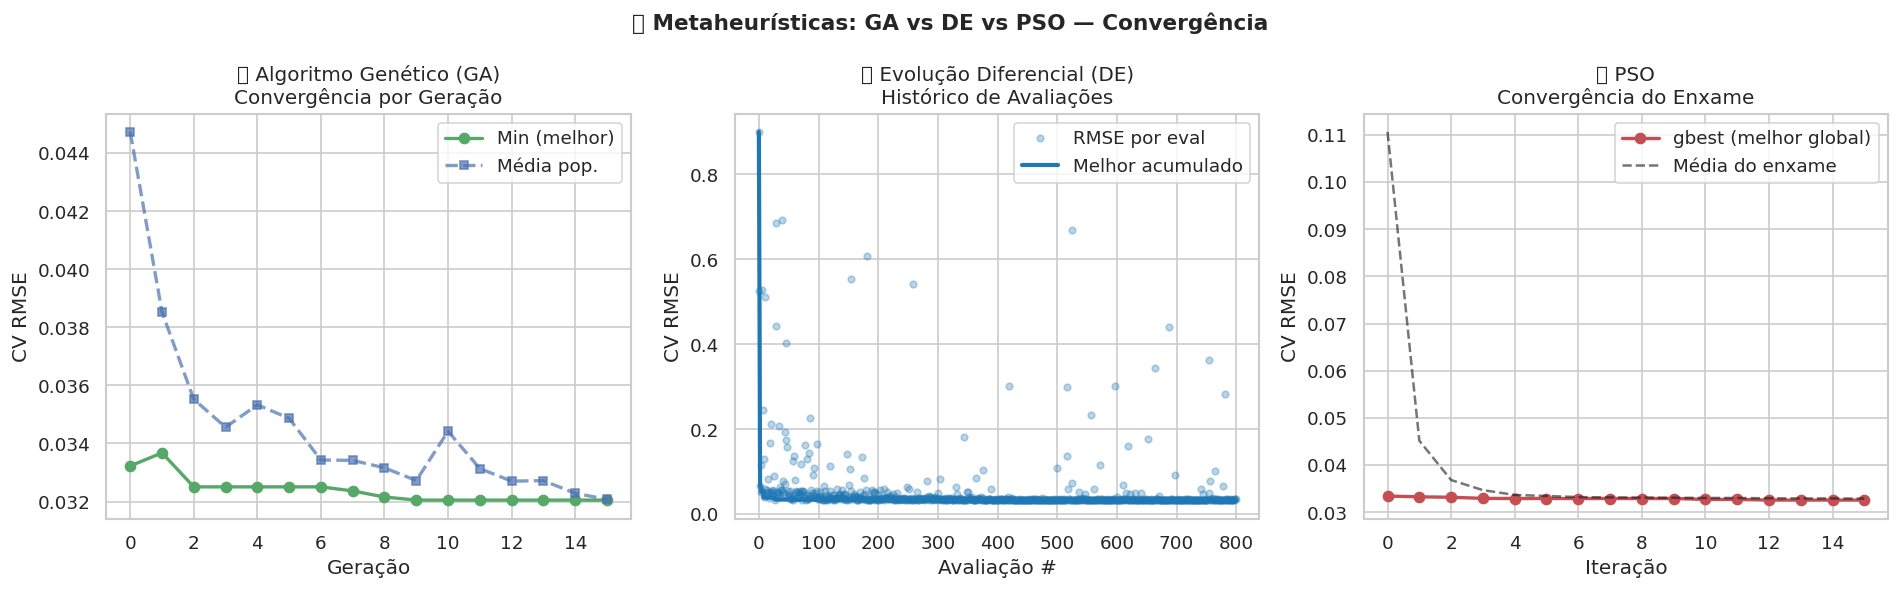

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# GA: convergência por geração
axes[0].plot(gen_list, gen_min,  'g-o', lw=2, ms=6, label='Min (melhor)')
axes[0].plot(gen_list, gen_mean, 'b--s', lw=2, ms=5, alpha=0.7, label='Média pop.')
axes[0].set_xlabel('Geração')
axes[0].set_ylabel('CV RMSE')
axes[0].set_title('🧬 Algoritmo Genético (GA)\nConvergência por Geração')
axes[0].legend()

# DE: histórico de avaliações
de_best_accum = [min(de_scores_list[:i+1]) for i in range(len(de_scores_list))]
axes[1].plot(de_scores_list, 'o', alpha=0.3, ms=4, color=PALETTE[0], label='RMSE por eval')
axes[1].plot(de_best_accum, '-', lw=2.5, color=PALETTE[0], label='Melhor acumulado')
axes[1].set_xlabel('Avaliação #')
axes[1].set_ylabel('CV RMSE')
axes[1].set_title('🔵 Evolução Diferencial (DE)\nHistórico de Avaliações')
axes[1].legend()

# PSO: convergência por iteração
axes[2].plot(pso.history_best, 'r-o', lw=2, ms=6, label='gbest (melhor global)')
axes[2].plot(pso.history_mean, 'k--', lw=1.5, alpha=0.6, label='Média do enxame')
axes[2].set_xlabel('Iteração')
axes[2].set_ylabel('CV RMSE')
axes[2].set_title('🐝 PSO\nConvergência do Enxame')
axes[2].legend()

plt.suptitle('🌿 Metaheurísticas: GA vs DE vs PSO — Convergência',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 📊 **Comparação de métricas e custo computacional**

**Métricas utilizadas**

| Métrica | Expressão | Interpretação |
|---------|--------|---------------|
| **RMSE** | $\sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$ | Penaliza erros grandes (mesma unidade) |
| **MAE** | $\frac{1}{n}\sum|y_i - \hat{y}_i|$ | Robusto a outliers |
| **R²** | $1 - \frac{SS_{res}}{SS_{tot}}$ | Variância explicada (1 = perfeito) |
| **Tempo** | $t_{\text{fim}} - t_{\text{início}}$ | Custo computacional real |

In [ ]:
df_res = pd.DataFrame(RESULTS)

# Adiciona coluna de eficiência
df_res['R²/Tempo'] = df_res['r2'] / df_res['Tempo(s)']
df_res['Rank RMSE'] = df_res['rmse'].rank().astype(int)

display(df_res[['Método','CV RMSE','rmse','mae','r2','Tempo(s)','N evals']]
    .rename(columns={'rmse':'Test RMSE','mae':'Test MAE','r2':'Test R²'})
    .style
    .highlight_min(subset=['CV RMSE','Test RMSE','Test MAE'], color='#c8f7c5')
    .highlight_max(subset=['Test R²'], color='#c8f7c5')
    .highlight_min(subset=['Tempo(s)'], color='#fef9c3')
    .format({'CV RMSE':'{:.4f}','Test RMSE':'{:.4f}','Test MAE':'{:.4f}',
             'Test R²':'{:.4f}','Tempo(s)':'{:.1f}'})
    .set_caption('📊 Comparação Final — UCI Household Power Consumption')
)
print('\n🟢 Verde: melhor métrica | 🟡 Amarelo: menor tempo')

,Método,CV RMSE,Test RMSE,Test MAE,Test R²,Tempo(s),N evals
0,Grid Search,0.0318,0.0323,0.0194,0.9990,88.0,54
1,Random Search,0.0326,0.0343,0.0201,0.9988,42.9,30
2,skopt (GP+EI),0.0323,0.0317,0.0198,0.9990,508.5,40
3,bayes_opt (GP+UCB),0.0334,0.0318,0.0195,0.9990,190.5,40
4,Optuna (TPE),0.0324,0.0322,0.0199,0.9990,118.0,50
5,Hyperopt (TPE),0.0317,0.0323,0.0196,0.9990,172.1,50
6,Ray Tune (ASHA+Optuna),0.0350,0.0335,0.0203,0.9989,234.2,40
7,GA (DEAP),0.0321,0.0317,0.0193,0.9990,1091.7,375
8,DE (scipy),0.0327,0.0319,0.0197,0.9990,540.4,800
9,PSO,0.0326,0.0316,0.0196,0.9990,263.7,320



🟢 Verde: melhor métrica | 🟡 Amarelo: menor tempo


#### **Visualização (métricas)**

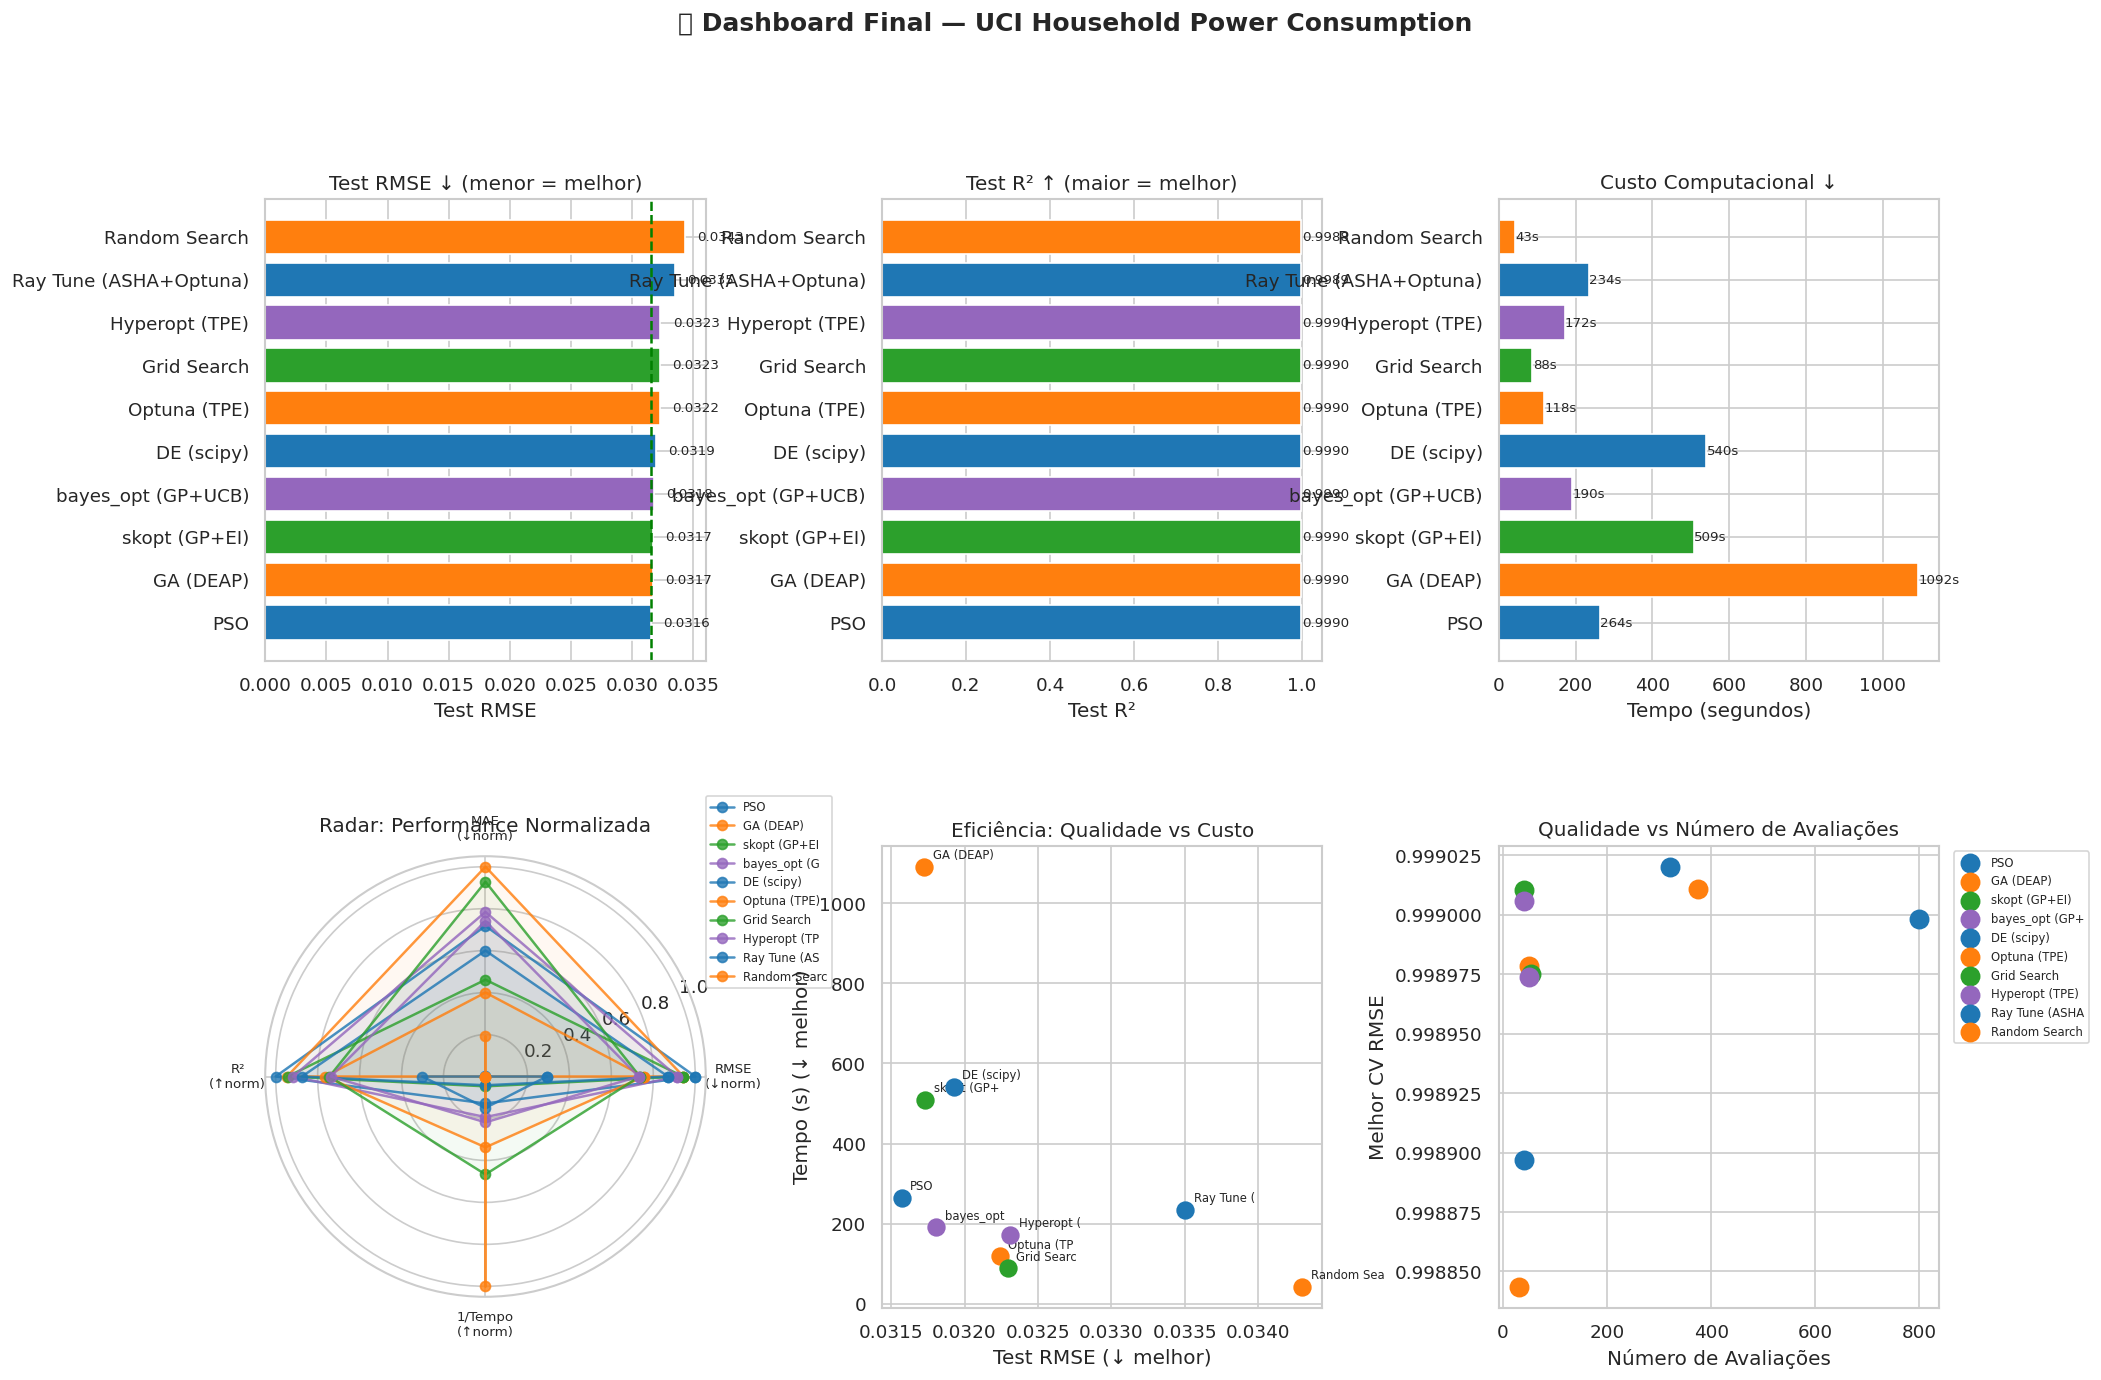

✅ Dashboard salvo como hpo_comparison_dashboard.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

# Ordena o DataFrame pelo RMSE
df_plot = df_res.sort_values('rmse')
methods = df_plot['Método'].tolist()
colors_plot = [PALETTE[i % len(PALETTE)] for i in range(len(methods))]

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.4)

# 1. Test RMSE (barras)
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.barh(methods, df_plot['rmse'], color=colors_plot, edgecolor='white')
ax1.axvline(df_plot['rmse'].min(), color='green', ls='--', lw=1.5)
ax1.set_xlabel('Test RMSE')
ax1.set_title('Test RMSE ↓ (menor = melhor)')
for bar, v in zip(bars, df_plot['rmse']):
    ax1.text(v + 0.001, bar.get_y() + bar.get_height()/2,
             f'{v:.4f}', va='center', fontsize=8)

# 2. Test R²
ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.barh(methods, df_plot['r2'], color=colors_plot, edgecolor='white')
ax2.set_xlabel('Test R²')
ax2.set_title('Test R² ↑ (maior = melhor)')
for bar, v in zip(bars2, df_plot['r2']):
    ax2.text(v + 0.001, bar.get_y() + bar.get_height()/2,
             f'{v:.4f}', va='center', fontsize=8)

# 3. Tempo computacional
ax3 = fig.add_subplot(gs[0, 2])
bars3 = ax3.barh(methods, df_plot['Tempo(s)'], color=colors_plot, edgecolor='white')
ax3.set_xlabel('Tempo (segundos)')
ax3.set_title('Custo Computacional ↓')
for bar, v in zip(bars3, df_plot['Tempo(s)']):
    ax3.text(v + 0.5, bar.get_y() + bar.get_height()/2,
             f'{v:.0f}s', va='center', fontsize=8)

# 4. Radar plot: RMSE norm + MAE norm + R² + 1/Tempo norm
ax4 = fig.add_subplot(gs[1, 0], projection='polar')
categories = ['RMSE\n(↓norm)', 'MAE\n(↓norm)', 'R²\n(↑norm)', '1/Tempo\n(↑norm)']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]

# Normalização
rmse_n  = 1 - (df_plot['rmse'] - df_plot['rmse'].min()) / (df_plot['rmse'].max() - df_plot['rmse'].min() + 1e-9)
mae_n   = 1 - (df_plot['mae']  - df_plot['mae'].min())  / (df_plot['mae'].max()  - df_plot['mae'].min()  + 1e-9)
r2_n    = (df_plot['r2']   - df_plot['r2'].min())    / (df_plot['r2'].max()   - df_plot['r2'].min()   + 1e-9)
inv_t_n = (1/df_plot['Tempo(s)'] - (1/df_plot['Tempo(s)']).min()) / ((1/df_plot['Tempo(s)']).max() - (1/df_plot['Tempo(s)']).min() + 1e-9)

for i, (method, rm, ma, r2, it, c) in enumerate(
        zip(methods, rmse_n, mae_n, r2_n, inv_t_n, colors_plot)):
    vals = [rm, ma, r2, it, rm]
    ax4.plot(angles, vals, 'o-', lw=1.5, label=str(method)[:12], color=c, alpha=0.8)
    ax4.fill(angles, vals, alpha=0.05, color=c)

ax4.set_xticks(angles[:-1])
ax4.set_xticklabels(categories, fontsize=8)
ax4.set_title('Radar: Performance Normalizada', pad=15)
ax4.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15), fontsize=7)

# 5. Scatter: RMSE vs Tempo (eficiência)
ax5 = fig.add_subplot(gs[1, 1])
for i, (_, row) in enumerate(df_plot.iterrows()):
    c = colors_plot[i]
    ax5.scatter(row['rmse'], row['Tempo(s)'], s=100, color=c, zorder=5)
    ax5.annotate(str(row['Método'])[:10], (row['rmse'], row['Tempo(s)']),
                 fontsize=7, xytext=(5, 5), textcoords='offset points')
ax5.set_xlabel('Test RMSE (↓ melhor)')
ax5.set_ylabel('Tempo (s) (↓ melhor)')
ax5.set_title('Eficiência: Qualidade vs Custo')

# 6. Convergência compilada (CV RMSE por método com n_evals)
ax6 = fig.add_subplot(gs[1, 2])
# Nota: certifique-se de que a coluna contendo o CV RMSE no seu DataFrame se chama 'cv_rmse' ou altere abaixo
cv_col = 'cv_rmse' if 'cv_rmse' in df_plot.columns else df_plot.columns[4]

for i, (_, row) in enumerate(df_plot.iterrows()):
    c = colors_plot[i]
    ax6.scatter(row['N evals'], row[cv_col],
                s=120, color=c, label=str(row['Método'])[:14], zorder=5)
ax6.set_xlabel('Número de Avaliações')
ax6.set_ylabel('Melhor CV RMSE')
ax6.set_title('Qualidade vs Número de Avaliações')
ax6.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc='upper left')

fig.suptitle('🏆 Dashboard Final — UCI Household Power Consumption',
             fontsize=15, fontweight='bold', y=1.01)

plt.savefig('hpo_comparison_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Dashboard salvo como hpo_comparison_dashboard.png')

### **Visualização: Predições do melhor modelo**

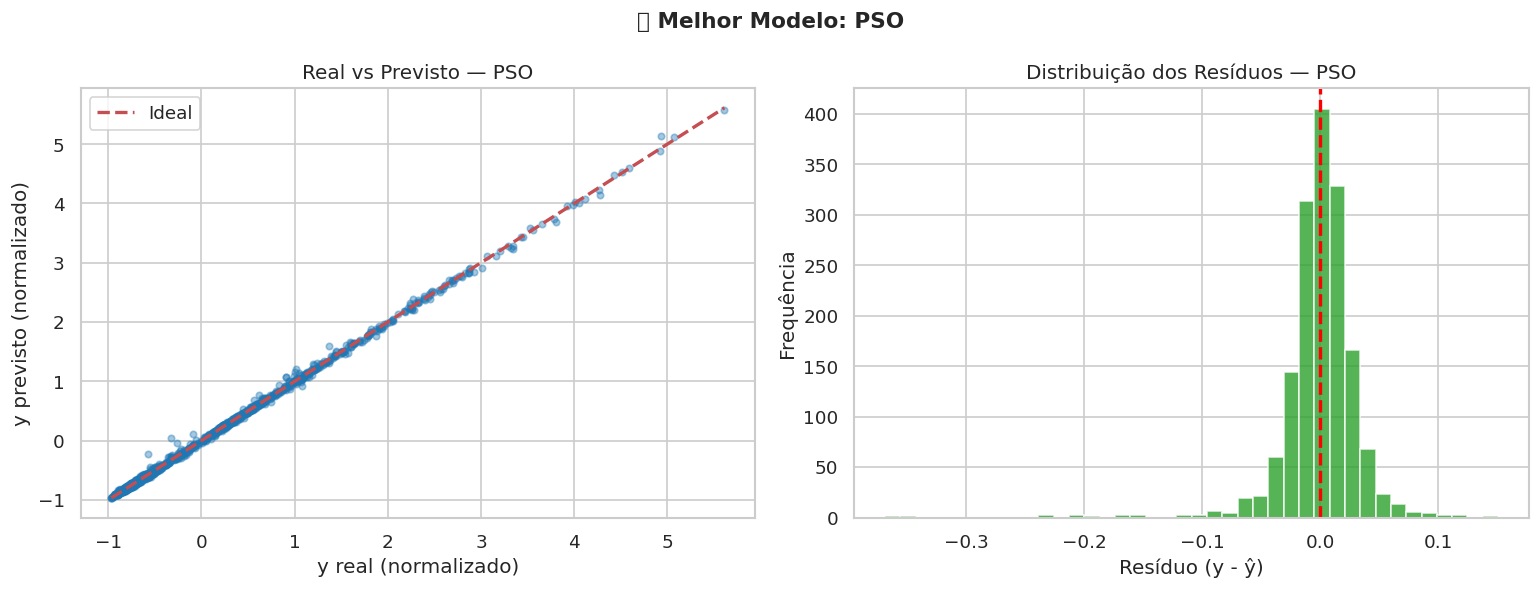

In [ ]:
best_idx   = df_res['rmse'].idxmin()
best_name  = df_res.loc[best_idx, 'Método']

# Mapa de modelos
model_map = {
    'Grid Search'          : grid_cv.best_estimator_,
    'Random Search'        : rand_cv.best_estimator_,
    'skopt (GP+EI)'        : bayes_skopt.best_estimator_,
    'bayes_opt (GP+UCB)'   : model_bo,
    'Optuna (TPE)'         : model_optuna,
    'Hyperopt (TPE)'       : model_hpo,
    'Ray Tune (ASHA+Optuna)': model_ray,
    'GA (DEAP)'            : model_ga,
    'DE (scipy)'           : model_de,
    'PSO'                  : model_pso
}

best_model = model_map.get(best_name)
y_pred_best = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: previsto vs real
axes[0].scatter(y_test, y_pred_best, alpha=0.4, s=15, color=PALETTE[0])
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Ideal')
axes[0].set_xlabel('y real (normalizado)')
axes[0].set_ylabel('y previsto (normalizado)')
axes[0].set_title(f'Real vs Previsto — {best_name}')
axes[0].legend()

# Resíduos
residuals = y_test - y_pred_best
axes[1].hist(residuals, bins=40, color=PALETTE[2], alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='red', ls='--', lw=2)
axes[1].set_xlabel('Resíduo (y - ŷ)')
axes[1].set_ylabel('Frequência')
axes[1].set_title(f'Distribuição dos Resíduos — {best_name}')

plt.suptitle(f'🏆 Melhor Modelo: {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 📊 **Comentários**

### <font color="blue">**Hierarquia recomendada**</font>

| Prioridade | Método | Quando usar | Custo |
|-----------|--------|-------------|-------|
| 🥇 1º | **Optuna** (TPE + Pruning) | Geral — melhor custo-benefício | Médio |
| 🥈 2º | **Ray Tune** (ASHA) | Escala distribuída, GPU clusters | Baixo/paralelo |
| 🥉 3º | **skopt** (GP + EI) | Orçamento muito limitado (< 30 evals) | Médio |
| 4º | **Hyperopt** (TPE) | Integração Spark, espaços condicionais | Médio |
| 5º | **bayes_opt** | Prototipagem rápida, benchmarks simples | Médio |
| 6º | **DE** (scipy) | Espaços contínuos sem bibliotecas HPO | Alto |
| 7º | **GA** (DEAP) | Problemas com restrições complexas | Alto |
| 8º | **PSO** | Problemas com restrições de vizinhança | Alto |
| 9º | **Random Search** | Baseline rápido, muitos parâmetros | Baixo |
| 10º | **Grid Search** | Apenas 1–2 parâmetros | Baixo |

#### **Sumário**

Necessita de uma análise estatística rodando n vezes para m problemas.

In [ ]:
df_summary = df_res.sort_values('rmse').reset_index(drop=True)

print('=' * 68)
print(' 🏆 SUMÁRIO FINAL — OTIMIZAÇÃO DE HIPERPARÂMETROS')
print(' Dataset: UCI Individual Household Electric Power Consumption')
print('=' * 68)
print()
print(f'{'Rank':<5} {'Método':<25} {'Test RMSE':>10} {'Test R²':>9} {'Tempo':>8}')
print('-' * 60)
for i, row in df_summary.iterrows():
    medal = ['🥇','🥈','🥉','4️⃣ ','5️⃣ ','6️⃣ ','7️⃣ ','8️⃣ ','9️⃣ ','🔟'][min(i, 9)]
    print(f'{medal}   {row["Método"]:<25} {row["rmse"]:>10.4f} {row["r2"]:>9.4f} {row["Tempo(s)"]:>7.1f}s')
print()
print(f'  Melhor RMSE  : {df_summary["Método"].iloc[0]} ({df_summary["rmse"].iloc[0]:.4f})')
print(f'  Melhor R²    : {df_summary.loc[df_summary["r2"].idxmax(),"Método"]} ({df_summary["r2"].max():.4f})')
print(f'  Mais rápido  : {df_summary.loc[df_summary["Tempo(s)"].idxmin(),"Método"]} ({df_summary["Tempo(s)"].min():.1f}s)')
print()
print('  Recomendação: Optuna (TPE) oferece o melhor custo-benefício na maioria')
print('  dos casos. Para datasets grandes, combine com Ray Tune para paralelismo.')
print()
print('=' * 68)

 🏆 SUMÁRIO FINAL — OTIMIZAÇÃO DE HIPERPARÂMETROS
 Dataset: UCI Individual Household Electric Power Consumption

Rank  Método                     Test RMSE   Test R²    Tempo
------------------------------------------------------------
🥇   PSO                           0.0316    0.9990   263.7s
🥈   GA (DEAP)                     0.0317    0.9990  1091.7s
🥉   skopt (GP+EI)                 0.0317    0.9990   508.5s
4️⃣    bayes_opt (GP+UCB)            0.0318    0.9990   190.5s
5️⃣    DE (scipy)                    0.0319    0.9990   540.4s
6️⃣    Optuna (TPE)                  0.0322    0.9990   118.0s
7️⃣    Grid Search                   0.0323    0.9990    88.0s
8️⃣    Hyperopt (TPE)                0.0323    0.9990   172.1s
9️⃣    Ray Tune (ASHA+Optuna)        0.0335    0.9989   234.2s
🔟   Random Search                 0.0343    0.9988    42.9s

  Melhor RMSE  : PSO (0.0316)
  Melhor R²    : PSO (0.9990)
  Mais rápido  : Random Search (42.9s)

  Recomendação: Optuna (TPE) oferece o melhor 

# 📝 Lista de exercícios - Aula 05

### **Requisitos**
* **Grupos** de 1 a 3 pessoas.
* **Enviar** para leandro.coelho@ufpr.br o notebook Jupyter com o nome dos integrantes do grupo, os resultados e as análises.
* **Corpo** do email: Nomes dos integrantes do grupo.
* **Assunto** do email: Avanços em IA - Exercícios da aula 05.
* **Anexo** ao email: Notebook Jupyter com resultados e as análises solicitados nos exercícios, e um arquivo PDF com resultados e as análises.
* Cada grupo deve escolher **1 dataset real** dentre os **10 sugeridos** (tabela na seção **Enunciados**) e aplicar sobre ele o **Exercício 1** e o **Exercício 2** — ambos incidem sobre o **mesmo dataset** e, juntos, retomam todo o roteiro de clustering apresentado nesta aula. Datasets diferentes dos sugeridos podem ser usados mediante aprovação prévia do professor.
* <font color="red"><b>Deadline para envio da lista de exercícios resolvida por email:</b> 30 de setembro de 2026</font>


### **Enunciados**

**Datasets sugeridos (escolha 1 dentre os 10)**

Os exercícios aplicam otimização de hiperparâmetros sobre **tarefas de regressão ou classificação** em dados reais de engenharia, energia ou ciências aplicadas.

O foco está no **processo de HPO**, não na tarefa em si. Escolha um dataset com volume suficiente (preferencialmente ≥ 1000 amostras) e ao menos 4 atributos (features).

---

| # | Dataset | Tarefa | Variáveis / Alvo | Fonte UCI / Repositório |
|---|---------|--------|--------------------|-------------------------|
| 1 | **Individual Household Electric Power Consumption** | Regressão | 6 features elétricas → Global Active Power | [UCI id=235](https://archive.ics.uci.edu/dataset/235) |
| 2 | **Combined Cycle Power Plant** | Regressão | T, V, AP, RH → PE (potência líquida) | [UCI id=294](https://archive.ics.uci.edu/dataset/294) |
| 3 | **Energy Efficiency** | Regressão | 8 características arquitetônicas → Heating/Cooling load | [UCI id=242](https://archive.ics.uci.edu/dataset/242) |
| 4 | **Concrete Compressive Strength** | Regressão | 8 ingredientes → resistência à compressão (MPa) | [UCI id=165](https://archive.ics.uci.edu/dataset/165) |
| 5 | **Air Quality** | Regressão | Sensores de gases → concentração de CO/NOx | [UCI id=360](https://archive.ics.uci.edu/dataset/360) |
| 6 | **Appliances Energy Prediction** | Regressão | T, umidade, hora → consumo de eletrodomésticos (Wh) | [UCI id=374](https://archive.ics.uci.edu/dataset/374) |
| 7 | **Superconductivty Data** | Regressão | 81 features físicas → temperatura crítica (K) | [UCI id=464](https://archive.ics.uci.edu/dataset/464) |
| 8 | **Wine Quality (Red + White)** | Regressão ou Classificação | 11 físico-químicas → qualidade (0–10) | [UCI id=186](https://archive.ics.uci.edu/dataset/186) |
| 9 | **Default of Credit Card Clients** | Classificação | 23 variáveis socioeconômicas → default (0/1) | [UCI id=350](https://archive.ics.uci.edu/dataset/350) |
| 10 | **Dry Bean Dataset** | Classificação | 16 atributos morfológicos → 7 classes de feijão | [UCI id=602](https://archive.ics.uci.edu/dataset/602) |

---

> **Carregamento padronizado (todos os 10 datasets estão no UCI ML Repository):**
> ```python
> from ucimlrepo import fetch_ucirepo
> ds = fetch_ucirepo(id=XXX)   # substitua XXX pelo id da tabela acima
> X = ds.data.features
> y = ds.data.targets
> ```


<font color="blue"><b>Exercício 1 — Baseline, Busca aleatória, Busca em grade,análise do espaço de hiperparâmetros</b></font>

Cobre os Módulos 0–2 da aula: preparação do dataset, métodos clássicos de HPO e análise exploratória do espaço de hiperparâmetros.

Escolha **um** dos 10 datasets sugeridos e um algoritmo de aprendizado supervisionado (`GradientBoostingRegressor` ou `GradientBoostingClassifier` dependendo da tarefa). Execute as etapas a seguir sobre o mesmo par (dataset, algoritmo) ao longo de **todo o Exercício 1**.

---

**1. Carregamento e pré-processamento**

1.1. Carregue o dataset via `ucimlrepo` e exiba: shape, tipos das colunas, proporção de valores ausentes por coluna e estatísticas descritivas (`describe()`).

1.2. Trate valores ausentes (imputação ou remoção — justifique a estratégia), remova duplicatas se existirem e aplique `StandardScaler` às features numéricas.

1.3. Divida em treino (80%) e teste (20%) com `random_state=42`. Para classificação, use `stratify=y`.

1.4. Apresente uma EDA com: histograma do target, mapa de calor de correlação e pelo menos um scatter plot relevante entre features e target.

---

**2. Modelo baseline (sem otimização)**

2.1. Treine o modelo com os **hiperparâmetros padrão** do sklearn e registre:
  - Para regressão: RMSE, MAE e R² no conjunto de teste.
  - Para classificação: acurácia, F1-macro e AUC-ROC no conjunto de teste.
  - Tempo de treinamento (`time.perf_counter()`).

2.2. Gere o gráfico de **Real vs. Previsto** (regressão) ou **Matriz de Confusão** (classificação) para o baseline.

---

**3. Busca em grade**

3.1. Defina uma grade com **pelo menos 3 hiperparâmetros** e aplique `GridSearchCV` com `cv=5` e a mesma métrica de avaliação do baseline.
Calcule: número total de combinações avaliadas, melhor CV score, melhores hiperparâmetros, tempo total e métricas no conjunto de teste.

3.2. Plote a **curva de convergência**: melhor score acumulado por número de avaliações.

3.3. Utilizando os resultados do `cv_results_`, gere um **heatmap 2D** do score médio de CV em função de dois hiperparâmetros (fixando os demais no valor ótimo encontrado). Interprete: a superfície é suave? Há múltiplos ótimos locais?

---

**4. Busca aleatória**

4.1. Aplique `RandomizedSearchCV` com `n_iter=30` sobre o **mesmo espaço** do Grid Search. Registre as mesmas métricas do item 3.1.

4.2. Plote a curva de convergência do Random Search e sobreponha à do Grid Search em um único gráfico. Interprete: com qual número de avaliações o Random Search supera o melhor Grid Search?

4.3. Analise a **importância empírica de cada hiperparâmetro**: para cada hiperparâmetro, calcule a correlação de Spearman entre seu valor e o CV score nos trials do Random Search. Qual hiperparâmetro tem maior impacto? Esse resultado é consistente com o esperado para o algoritmo escolhido?

---

**5. Síntese do exercício 1**

5.1. Monte uma tabela comparativa com: Método, CV Score, Test RMSE (ou F1), Tempo (s) e N° de avaliações — para o Baseline, Grid Search e Random Search.

5.2. Responda objetivamente (2–4 linhas cada):
  - A otimização trouxe ganho real em relação ao baseline? O ganho justifica o custo computacional?
  - Em que cenários o Grid Search ainda é preferível ao Random Search?
  - O heatmap revelou alguma interação relevante entre hiperparâmetros?


In [ ]:
# ─── Exercício 1 — Template de Código ────────────────────────────────────────
# INSTRUÇÕES: preencha as seções marcadas com TODO.
# Não apague os comentários de seção — eles guiam a correção.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                              accuracy_score, f1_score, roc_auc_score,
                              confusion_matrix, ConfusionMatrixDisplay)
from scipy.stats import spearmanr

np.random.seed(42)
DATASET_ID = None   # TODO: substitua pelo id do dataset escolhido (ex: 235)
TASK       = None   # TODO: 'regression' ou 'classification'

# ── 1. Carregamento ───────────────────────────────────────────────────────────
# TODO: carregue o dataset, exiba shape, dtypes, missing values e describe()

# ── 2. Pré-processamento ──────────────────────────────────────────────────────
# TODO: trate NaN, normalize, divida treino/teste

# ── 3. Baseline ───────────────────────────────────────────────────────────────
# TODO: treine com parâmetros default, registre métricas e tempo

# ── 4. Grid Search ────────────────────────────────────────────────────────────
param_grid = {
    # TODO: defina ao menos 3 hiperparâmetros com 3-4 valores cada
    # Exemplo: 'n_estimators': [50, 100, 200], ...
}

# TODO: GridSearchCV + métricas + heatmap 2D

# ── 5. Random Search ─────────────────────────────────────────────────────────
# TODO: RandomizedSearchCV (n_iter=30) + métricas + correlação de Spearman

# ── 6. Síntese ────────────────────────────────────────────────────────────────
# TODO: tabela comparativa + interpretação

<font color="blue"><b>Exercício 2 — Otimização Bayesiana, metaheurísticas e avaliação</b></font>

Continue sobre o **mesmo dataset e o mesmo algoritmo** do Exercício 1. Mantenha os mesmos splits treino/teste e o mesmo protocolo de validação cruzada (`cv=5`, `random_state=42`).

---

**6. Gaussian Process como Surrogate Model (demonstração)**

6.1. Escolha **dois hiperparâmetros contínuos** do seu modelo (ex: `learning_rate` e `subsample`). Implemente — do zero, sem usar `BayesSearchCV` — o loop de Bayesian Optimization com GP:
  - Inicialize com 5 pontos aleatórios;
  - A cada iteração: ajuste um `GaussianProcessRegressor` (kernel Matérn 5/2) sobre as observações anteriores; maximize a **Expected Improvement** para escolher o próximo ponto; avalie o modelo nesse ponto.
  - Execute 10 iterações.

6.2. Para cada iteração, plote: (a) o posterior do GP (média ± 2σ) e as observações; (b) a curva de EI com o próximo ponto destacado. Comente: a incerteza do GP diminui conforme esperado? O EI converge para a região ótima?

6.3. Compare o RMSE/F1 do melhor ponto encontrado pelo GP (item 6.1) com os resultados do Grid e Random Search do Exercício 1. O GP foi mais eficiente em número de avaliações?

---

**7. Bibliotecas de Bayesian Optimization — espaço completo**

Aplique as **5 bibliotecas** a seguir sobre o **espaço completo de hiperparâmetros** (o mesmo do Exercício 1, com pelo menos 3 hiperparâmetros). Use `n_iter=40` (ou equivalente) em cada uma:

| # | Biblioteca | Configuração mínima exigida |
|---|-----------|-----------------------------|
| 7.1 | `scikit-optimize` (`BayesSearchCV`) | GP + EI, kernel Matérn 5/2 |
| 7.2 | `bayesian-optimization` (`BayesianOptimization`) | GP + UCB, `kappa=2.576` |
| 7.3 | `Optuna` | Sampler TPE, `direction='minimize'` (RMSE) ou `'maximize'` (F1) |
| 7.4 | `Hyperopt` | `tpe.suggest`, `hp.loguniform` para LR |
| 7.5 | `Ray Tune` | `OptunaSearch` + `ASHAScheduler` |

Para cada biblioteca registre: melhor CV score, métricas no conjunto de teste, tempo total (s) e número de avaliações efetivas. Plote a curva de convergência de cada uma.

---

**8. Metaheurísticas — GA, DE e PSO**

Aplique os 3 algoritmos bioinspirados sobre o mesmo espaço de hiperparâmetros:

8.1. **Algoritmo genético (GA)** com DEAP:
  - Codificação inteira dos hiperparâmetros (ver seção 5.1 da aula).
  - População: 20 indivíduos; Gerações: 15; `cxpb=0.7`, `mutpb=0.25`.
  - Plote a curva de fitness mínimo e médio por geração.
  - Analise a diversidade da população ao longo das gerações: o algoritmo convergiu prematuramente?

8.2. **Evolução fiferencial (DE)** via `scipy.optimize.differential_evolution`:
  - Estratégia `best1bin`; `maxiter=15`, `popsize=10`, `mutation=(0.5, 1.0)`, `recombination=0.7`.
  - Registre a sequência de avaliações da função objetivo e plote a convergência.
  - Compare a estratégia `best1bin` com `rand1bin`: execute ambas e discuta a diferença no perfil de convergência.

8.3. **Otimização por enxame de partículas (PSO)** (implementado do zero, conforme Módulo 5.3 da aula):
  - 20 partículas, 15 iterações, `w=0.7`, `c1=1.5`, `c2=1.5`.
  - Plote a trajetória do gbest e a média do enxame por iteração.
  - Experimente valores diferentes de inércia (`w=0.4` e `w=0.9`) e discuta o impacto na convergência.

---

**9. Dashboard comparativo**

9.1. Monte uma tabela consolidando **todos os métodos** (Baseline, Grid, Random, GP-scratch, skopt, bayes_opt, Optuna, Hyperopt, Ray Tune, GA, DE, PSO) com as colunas:
  - CV Score; Test RMSE ou Test F1; Test MAE ou Test AUC; Test R² ou Test Acurácia; Tempo (s); N° de avaliações.
  - Destaque com cor verde o melhor valor em cada coluna de métrica de qualidade e com amarelo o menor tempo.

9.2. Construa um **radar chart** (gráfico aranha) com os 4 eixos normalizados: RMSE, MAE, R² (ou acurácia), 1/Tempo — um polígono por método. Quais métodos dominam em qualidade? Quais dominam em eficiência?

9.3. Gere um **scatter plot Qualidade × Custo** (eixo x = Test RMSE ou 1–F1; eixo y = Tempo em segundos). Identifique a **fronteira de Pareto** dos métodos não-dominados e destaque esses pontos no gráfico.

9.4. Para o **melhor método** identificado na tabela:
  - Gere o gráfico Real vs. Previsto (regressão) ou Matriz de Confusão (classificação) no conjunto de teste.
  - Plote o histograma dos resíduos e verifique normalidade (teste de Shapiro-Wilk).
  - Calcule e plote a **feature importance** do modelo final (se o algoritmo suportar).

---

**10. Análise crítica e recomendação**

10.1. **Importância dos hiperparâmetros** (Optuna `get_param_importances`): quais hiperparâmetros mais impactam o desempenho no seu dataset? Esse resultado muda se você usar o dataset inteiro ao invés da amostra?

10.2. Realize um experimento de **robustez**: execute o melhor método (por RMSE/F1) com 5 seeds diferentes (`random_state ∈ {0, 7, 21, 42, 99}`) e reporte a média e desvio padrão do Test RMSE ou F1. O resultado é estável?

10.3. **Custo-benefício computacional**: calcule a *razão de eficiência* = melhoria relativa do Test Score em relação ao baseline dividida pelo tempo adicional gasto. Qual método apresenta melhor razão?

10.4. Redija uma **recomendação justificada** (máx. 10 linhas) respondendo: *"Qual método de HPO você adotaria em produção para este dataset/algoritmo, e por quê?"* Considere: qualidade do modelo, custo computacional, reprodutibilidade e facilidade de integração em pipelines automatizados.


In [ ]:
# ─── Exercício 2 — Seção 6: GP do zero ──────────────────────────────────────
# INSTRUÇÕES: implemente o loop de BO com GP para 2 hiperparâmetros.

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, WhiteKernel
from scipy.stats import norm

def acquisition_EI(X_cand, X_obs, y_obs, gp, xi=0.01):
    """Expected Improvement — minimização."""
    mu, sigma = gp.predict(X_cand, return_std=True)
    f_best = np.min(y_obs)
    imp = f_best - mu - xi
    Z   = imp / (sigma + 1e-9)
    ei  = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma < 1e-10] = 0.0
    return ei

# TODO: defina os 2 hiperparâmetros e seus limites
# hp1_name, hp1_bounds = 'learning_rate', (0.01, 0.3)
# hp2_name, hp2_bounds = 'subsample',     (0.6, 1.0)

# TODO: grade de avaliação 2D para visualização
# TODO: inicialize com 5 pontos aleatórios e execute 10 iterações
# TODO: a cada iteração: plote posterior GP + EI

print('Seção 6 — GP do zero: a implementar')

In [ ]:
# ─── Exercício 2 — Seção 7: Bibliotecas de BO ───────────────────────────────
# INSTRUÇÕES: aplique as 5 bibliotecas com n_iter=40 (ou equivalente).
# Mantenha o mesmo espaço de hiperparâmetros do Exercício 1.

# Imports necessários — descomente conforme usar
# from skopt import BayesSearchCV
# from skopt.space import Integer, Real
# from bayes_opt import BayesianOptimization
# import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)
# from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
# import ray; from ray import tune; from ray.tune.search.optuna import OptunaSearch
# from ray.tune.schedulers import ASHAScheduler

RESULTS_EX2 = []  # lista de dicts: {'Método':..., 'CV Score':..., ...}

# 7.1 scikit-optimize ─────────────────────────────────────────────────────────
# TODO

# 7.2 bayes_opt ───────────────────────────────────────────────────────────────
# TODO

# 7.3 Optuna ──────────────────────────────────────────────────────────────────
# TODO

# 7.4 Hyperopt ────────────────────────────────────────────────────────────────
# TODO

# 7.5 Ray Tune ────────────────────────────────────────────────────────────────
# TODO

print('Seção 7 — Bibliotecas de BO: a implementar')

In [ ]:
# ─── Exercício 2 — Seção 8: Metaheurísticas ─────────────────────────────────
# INSTRUÇÕES: implemente GA (DEAP), DE (scipy) e PSO (do zero).

# GA ──────────────────────────────────────────────────────────────────────────
from deap import base, creator, tools, algorithms
import random; random.seed(42)

# TODO: codificação inteira dos hiperparâmetros
# TODO: pop=20, ngen=15, cxpb=0.7, mutpb=0.25
# TODO: plote fitness min e médio por geração

# DE ──────────────────────────────────────────────────────────────────────────
from scipy.optimize import differential_evolution

# TODO: strategy='best1bin', maxiter=15, popsize=10
# TODO: repita com 'rand1bin' e compare as curvas

# PSO ─────────────────────────────────────────────────────────────────────────
# (reutilize a classe PSO da aula ou reimplemente aqui)

# TODO: n_particles=20, n_iters=15, w=0.7, c1=1.5, c2=1.5
# TODO: repita com w=0.4 e w=0.9; plote as 3 curvas de convergência

print('Seção 8 — Metaheurísticas: a implementar')

In [ ]:
# ─── Exercício 2 — Seção 9 + 10: Dashboard e Análise Crítica ────────────────
# INSTRUÇÕES: consolide RESULTS_EX1 e RESULTS_EX2 em um único DataFrame
# e gere os gráficos solicitados.

import matplotlib.gridspec as gridspec
from scipy.stats import shapiro

# Combine resultados
# df_all = pd.concat([pd.DataFrame(RESULTS_EX1), pd.DataFrame(RESULTS_EX2)], ignore_index=True)

# 9.1 Tabela comparativa completa ─────────────────────────────────────────────
# TODO: highlight_min (métricas de erro) + highlight_max (R², F1)

# 9.2 Radar chart ─────────────────────────────────────────────────────────────
# TODO: 4 eixos normalizados (RMSE, MAE, R²/Acurácia, 1/Tempo)

# 9.3 Scatter Qualidade × Custo + fronteira de Pareto ─────────────────────────
# TODO: identifique pontos não-dominados

# 9.4 Melhor modelo: Real vs Previsto / Conf. Matrix + resíduos + feature imp. ─
# TODO

# 10.2 Robustez: 5 seeds ──────────────────────────────────────────────────────
# seeds = [0, 7, 21, 42, 99]
# TODO: execute o melhor método para cada seed, reporte média ± std

# 10.3 Razão de eficiência ────────────────────────────────────────────────────
# razao = (score_metodo - score_baseline) / (tempo_metodo - tempo_baseline)
# TODO

# 10.4 Recomendação (resposta em célula Markdown abaixo) ─────────────────────

print('Seção 9-10 — Dashboard e análise crítica: a implementar')

#### Recomendação justificada

> *(Preencha aqui com no máximo 10 linhas a sua recomendação de qual método de HPO adotar em produção para o dataset e algoritmo escolhidos, justificando com base nos resultados quantitativos obtidos.)*

**Método recomendado:** `[PREENCHER]`

**Justificativa:**

...


### **Material de apoio**

**Carregamento de dados**
- [ucimlrepo — documentação](https://github.com/uci-ml-repo/ucimlrepo)
- [pandas.DataFrame.describe](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html)

**Pré-processamento**
- [sklearn.preprocessing.StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)
- [sklearn.model_selection.train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

**Métodos clássicos**
- [sklearn.model_selection.GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)
- [sklearn.model_selection.RandomizedSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html)
- [scipy.stats.spearmanr](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html)

**Processo Gaussiano (Gaussian Process, GP)**
- [sklearn.gaussian_process.GaussianProcessRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.gaussian_process.GaussianProcessRegressor.html)
- [sklearn.gaussian_process.kernels.Matern](https://scikit-learn.org/stable/modules/generated/sklearn.gaussian_process.kernels.Matern.html)
- Rasmussen & Williams (2006). *Gaussian Processes for Machine Learning*. MIT Press. http://gaussianbook.com

**Bibliotecas de otimizaçao Bayesiana**
- [scikit-optimize — BayesSearchCV](https://scikit-optimize.github.io/stable/modules/generated/skopt.BayesSearchCV.html)
- [bayesian-optimization — BayesianOptimization](https://github.com/bayesian-optimization/BayesianOptimization)
- [Optuna — documentação](https://optuna.readthedocs.io/) · [optuna.importance](https://optuna.readthedocs.io/en/stable/reference/importance.html)
- [Hyperopt — documentação](http://hyperopt.github.io/hyperopt/)
- [Ray Tune — documentação](https://docs.ray.io/en/latest/tune/index.html)

**Metaheurísticas**
- [DEAP — documentação](https://deap.readthedocs.io/)
- [scipy.optimize.differential_evolution](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.differential_evolution.html)
- Kennedy & Eberhart (1995). Particle swarm optimization. *ICNN 1995*.

**Métricas e visualização**
- [sklearn.metrics — regressão](https://scikit-learn.org/stable/modules/classes.html#regression-metrics)
- [sklearn.metrics — classificação](https://scikit-learn.org/stable/modules/classes.html#classification-metrics)
- [scipy.stats.shapiro](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.shapiro.html)
- [matplotlib — radar chart (polar axes)](https://matplotlib.org/stable/gallery/specialty_plots/radar_chart.html)

## **Referências**

**Akiba, T., Sano, S., Yanase, T., Ohta, T., & Koyama, M. (2019).** Optuna: A next-generation hyperparameter optimization framework. *Proceedings of the 25th ACM SIGKDD International Conference on Knowledge Discovery & Data Mining*, 2623–2631. https://doi.org/10.1145/3292500.3330701

**Bergstra, J., & Bengio, Y. (2012).** Random search for hyper-parameter optimization. *Journal of Machine Learning Research*, 13, 281–305. https://jmlr.org/papers/v13/bergstra12a.html

**Bergstra, J., Bardenet, R., Bengio, Y., & Kégl, B. (2011).** Algorithms for hyper-parameter optimization. *Advances in Neural Information Processing Systems*, 24, 2546–2554.

**Bergstra, J., Yamins, D., & Cox, D. D. (2013).** Making a science of model search: Hyperparameter optimization in hundreds of dimensions for vision architectures. *Proceedings of the 30th International Conference on Machine Learning (ICML 2013)*, 115–123.

**Das, S., & Suganthan, P. N. (2011).** Differential evolution: A survey of the state-of-the-art. *IEEE Transactions on Evolutionary Computation*, 15(1), 4–31. https://doi.org/10.1109/TEVC.2010.2059031

**Feurer, M., & Hutter, F. (2019).** Hyperparameter optimization. In F. Hutter, L. Kotthoff, & J. Vanschoren (Eds.), *Automated Machine Learning* (pp. 3–33). Springer. https://doi.org/10.1007/978-3-030-05318-5_1

**Frazier, P. I. (2018).** A tutorial on Bayesian optimization. *arXiv preprint arXiv:1807.02811*. https://arxiv.org/abs/1807.02811

**Head, T., Kumar, M., Nahrstaedt, H., Louppe, G., & Shcherbatyi, I. (2018).** scikit-optimize/scikit-optimize. *Zenodo*. https://doi.org/10.5281/zenodo.1207017

**Hebrail, G., & Berard, A. (2012).** Individual household electric power consumption. UCI Machine Learning Repository. https://archive.ics.uci.edu/dataset/235

**Holland, J. H. (1975).** *Adaptation in natural and artificial systems*. University of Michigan Press.

**Hutter, F., Kotthoff, L., & Vanschoren, J. (Eds.) (2019).** *Automated machine learning: Methods, systems, challenges*. Springer. https://doi.org/10.1007/978-3-030-05318-5

**Kennedy, J., & Eberhart, R. (1995).** Particle swarm optimization. *Proceedings of ICNN'95 — International Conference on Neural Networks*, 4, 1942–1948. https://doi.org/10.1109/ICNN.1995.488968

**Li, L., Jamieson, K., DeSalvo, G., Rostamizadeh, A., & Talwalkar, A. (2017).** Hyperband: A novel bandit-based approach to hyperparameter optimization. *Journal of Machine Learning Research*, 18(185), 1–52. https://jmlr.org/papers/v18/16-558.html

**Liaw, R., Liang, E., Nishihara, R., Moritz, P., Gonzalez, J. E., & Stoica, I. (2018).** Tune: A research platform for distributed model selection and training. *ICML 2018 AutoML Workshop*. https://arxiv.org/abs/1807.05118

**Mockus, J. (1975).** On Bayesian methods for seeking the extremum. In *Optimization Techniques IFIP Technical Conference* (pp. 400–404). Springer.

**Nogueira, F. (2014).** Bayesian optimization: Open source constrained global optimization tool for Python. GitHub. https://github.com/bayesian-optimization/BayesianOptimization

**Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011).** Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830. https://jmlr.org/papers/v12/pedregosa11a.html

**Rasmussen, C. E., & Williams, C. K. I. (2006).** *Gaussian processes for machine learning*. MIT Press. http://gaussianbook.com

**Shi, Y., & Eberhart, R. (1998).** A modified particle swarm optimizer. *Proceedings of the 1998 IEEE International Conference on Evolutionary Computation*, 69–73. https://doi.org/10.1109/ICEC.1998.699146

**Snoek, J., Larochelle, H., & Adams, R. P. (2012).** Practical Bayesian optimization of machine learning algorithms. *Advances in Neural Information Processing Systems*, 25, 2951–2959.

**Storn, R., & Price, K. (1997).** Differential evolution — a simple and efficient heuristic for global optimization over continuous spaces. *Journal of Global Optimization*, 11(4), 341–359. https://doi.org/10.1023/A:1008202821328
